# Billboard Lexical Diversity Analysis (2000-2023)

How does lexical diversity relate to chart performance across genres?

## 1. Setup & Data Loading

In [42]:
# Libraries and setup
library(tidyverse)
library(ggplot2)
library(scales)
library(viridis)

options(scipen = 999)
theme_set(theme_minimal(base_size = 12))

# Color palette
genre_colors <- c(
  "POP" = "#FF6B6B",
  "HIP HOP" = "#4ECDC4",
  "COUNTRY" = "#FFD93D",
  "ROCK" = "#95E1D3",
  "R&B" = "#F38181",
  "ELECTRONIC" = "#AA96DA",
  "LATIN" = "#FCE77D",
  "OTHER" = "#C8C8C8"
)

In [43]:
# Load data
df <- read_csv('../../data/cleaned/billboard_lexical_analysis_ready.csv',
               show_col_types = FALSE)

df_analysis <- df %>%
  filter(has_complete_data == TRUE)

cat(sprintf("Total: %d songs, Analysis set: %d (%.1f%%)\n", 
            nrow(df), nrow(df_analysis), nrow(df_analysis)/nrow(df)*100))
cat(sprintf("Years: %d-%d, Genres: %d\n", 
            min(df$year), max(df$year), n_distinct(df_analysis$macro_genre)))

Total: 3427 songs, Analysis set: 2822 (82.3%)
Years: 2000-2023, Genres: 8


## 2. Exploratory Analysis

In [44]:
# Summary stats by genre
summary_stats <- df_analysis %>%
  group_by(macro_genre) %>%
  summarise(
    n = n(),
    mean_ttr = mean(ttr, na.rm = TRUE),
    median_ttr = median(ttr, na.rm = TRUE),
    sd_ttr = sd(ttr, na.rm = TRUE),
    mean_lexical_density = mean(lexical_density, na.rm = TRUE),
    mean_rare_word_ratio = mean(rare_word_ratio, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  arrange(desc(mean_ttr))

print(summary_stats)

# A tibble: 8 x 7
  macro_genre     n mean_ttr median_ttr sd_ttr mean_lexical_density
  <chr>       <int>    <dbl>      <dbl>  <dbl>                <dbl>
1 COUNTRY       267    0.354      0.349 0.0695                0.357
2 LATIN          51    0.349      0.361 0.0735                0.605
3 HIP HOP       706    0.330      0.323 0.0763                0.396
4 ROCK          166    0.314      0.314 0.0598                0.324
5 R&B           107    0.307      0.305 0.0782                0.329
6 OTHER         134    0.307      0.300 0.0898                0.394
7 POP          1333    0.292      0.279 0.0881                0.367
8 ELECTRONIC     58    0.279      0.263 0.101                 0.363
# i 1 more variable: mean_rare_word_ratio <dbl>


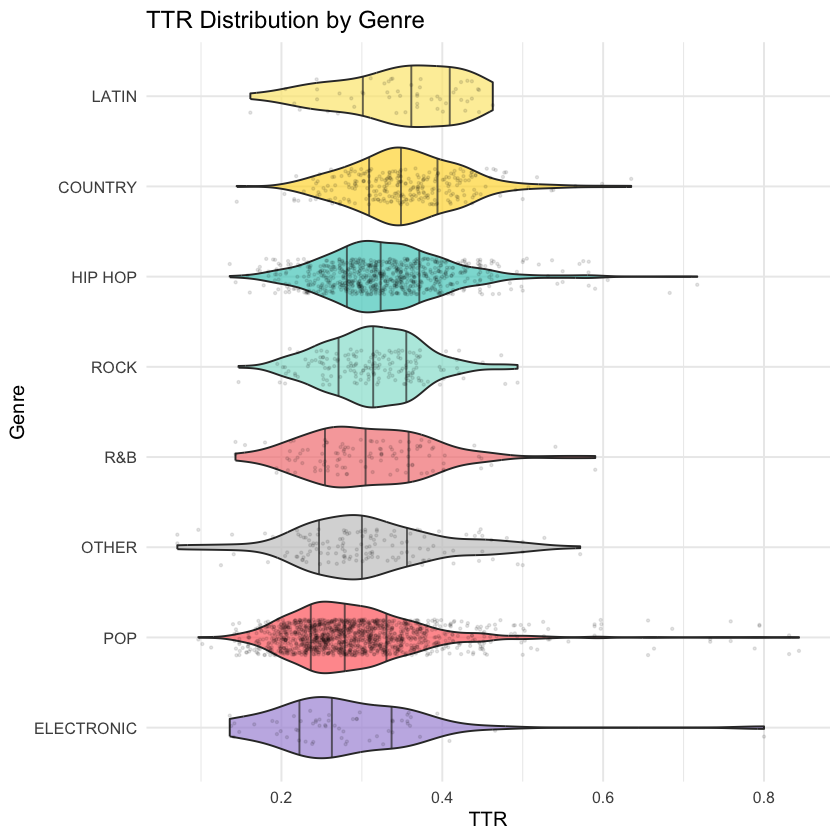

In [45]:
# TTR by genre
ggplot(df_analysis, aes(x = reorder(macro_genre, ttr, median), 
                        y = ttr, 
                        fill = macro_genre)) +
  geom_violin(alpha = 0.7, draw_quantiles = c(0.25, 0.5, 0.75)) +
  geom_jitter(alpha = 0.1, width = 0.2, size = 0.5) +
  scale_fill_manual(values = genre_colors) +
  labs(title = "TTR Distribution by Genre", x = "Genre", y = "TTR") +
  coord_flip() +
  theme(legend.position = "none")

## 3. Genre Comparison

In [46]:
# ANOVA: TTR across genres
anova_ttr <- aov(ttr ~ macro_genre, data = df_analysis)
summary(anova_ttr)
TukeyHSD(anova_ttr)

              Df Sum Sq Mean Sq F value              Pr(>F)    
macro_genre    7  1.365 0.19493   29.04 <0.0000000000000002 ***
Residuals   2814 18.891 0.00671                                
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = ttr ~ macro_genre, data = df_analysis)

$macro_genre
                            diff           lwr            upr     p adj
ELECTRONIC-COUNTRY -0.0747711895 -0.1107740488 -0.03876833025 0.0000000
HIP HOP-COUNTRY    -0.0240900655 -0.0419452104 -0.00623492066 0.0011403
LATIN-COUNTRY      -0.0048636702 -0.0428421679  0.03311482747 0.9999383
OTHER-COUNTRY      -0.0475196969 -0.0738301966 -0.02120919724 0.0000013
POP-COUNTRY        -0.0619814739 -0.0786445135 -0.04531843432 0.0000000
R&B-COUNTRY        -0.0474070595 -0.0758420588 -0.01897206022 0.0000125
ROCK-COUNTRY       -0.0405971611 -0.0651611682 -0.01603315408 0.0000157
HIP HOP-ELECTRONIC  0.0506811240  0.0167346030  0.08462764494 0.0001668
LATIN-ELECTRONIC    0.0699075193  0.0222008492  0.11761418942 0.0002450
OTHER-ELECTRONIC    0.0272514926 -0.0118100291  0.06631301433 0.4045871
POP-ELECTRONIC      0.0127897156 -0.0205452056  0.0461246368

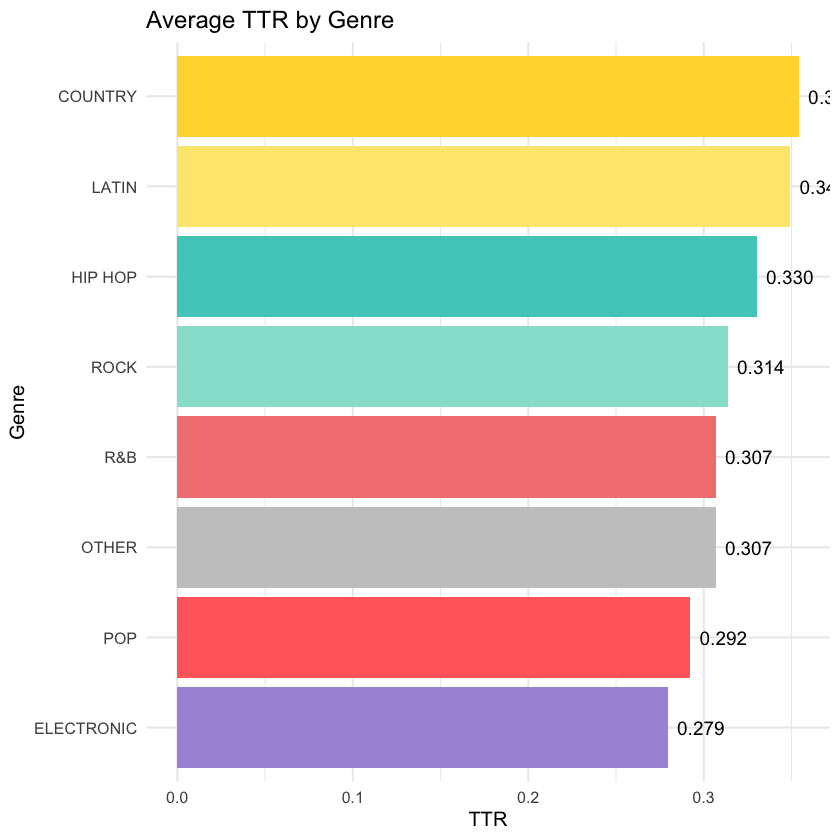

In [47]:
# Genre rankings bar chart
genre_rankings <- df_analysis %>%
  group_by(macro_genre) %>%
  summarise(
    n = n(),
    mean_ttr = mean(ttr, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  arrange(desc(mean_ttr))

ggplot(genre_rankings, aes(x = reorder(macro_genre, mean_ttr), 
                           y = mean_ttr, 
                           fill = macro_genre)) +
  geom_col() +
  geom_text(aes(label = sprintf("%.3f", mean_ttr)), hjust = -0.2, size = 4) +
  scale_fill_manual(values = genre_colors) +
  labs(title = "Average TTR by Genre", x = "Genre", y = "TTR") +
  coord_flip() +
  theme(legend.position = "none")

## 4. Chart Performance

In [48]:
# TTR vs chart position correlation
cor.test(df_analysis$ttr, df_analysis$ranking, method = "spearman")

Warning message in cor.test.default(df_analysis$ttr, df_analysis$ranking, method = "spearman"):
"Cannot compute exact p-value with ties"



	Spearman's rank correlation rho

data:  df_analysis$ttr and df_analysis$ranking
S = 3407678455, p-value = 0.000001586
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
0.09021476 


`geom_smooth()` using formula = 'y ~ x'


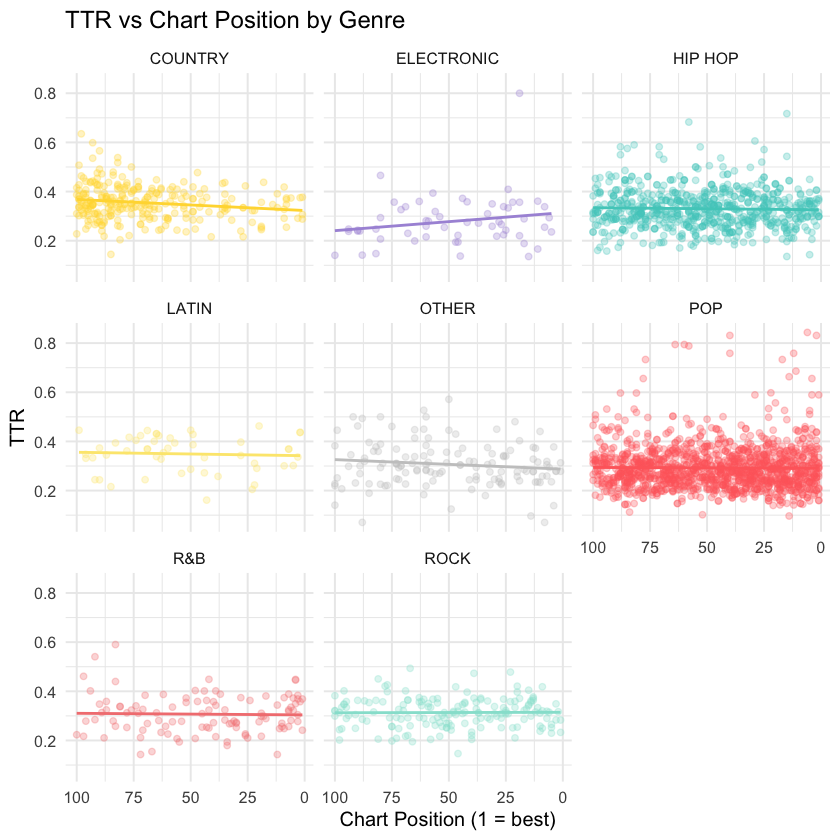

In [49]:
# TTR vs ranking scatter by genre
# X-axis reversed: 1 (best) on left, 100 on right
ggplot(df_analysis, aes(x = ranking, y = ttr, color = macro_genre)) +
  geom_point(alpha = 0.3, size = 1.5) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  scale_color_manual(values = genre_colors) +
  scale_x_reverse(limits = c(100, 1)) +
  facet_wrap(~macro_genre, ncol = 3) +
  labs(title = "TTR vs Chart Position by Genre", 
       x = "Chart Position (1 = best)", 
       y = "TTR") +
  theme(legend.position = "none")

Warning message in cor.test.default(df_analysis$rare_word_ratio, df_analysis$ranking, :
"Cannot compute exact p-value with ties"


Rare words vs Ranking: rho = -0.003, p = 0.8717


`geom_smooth()` using formula = 'y ~ x'


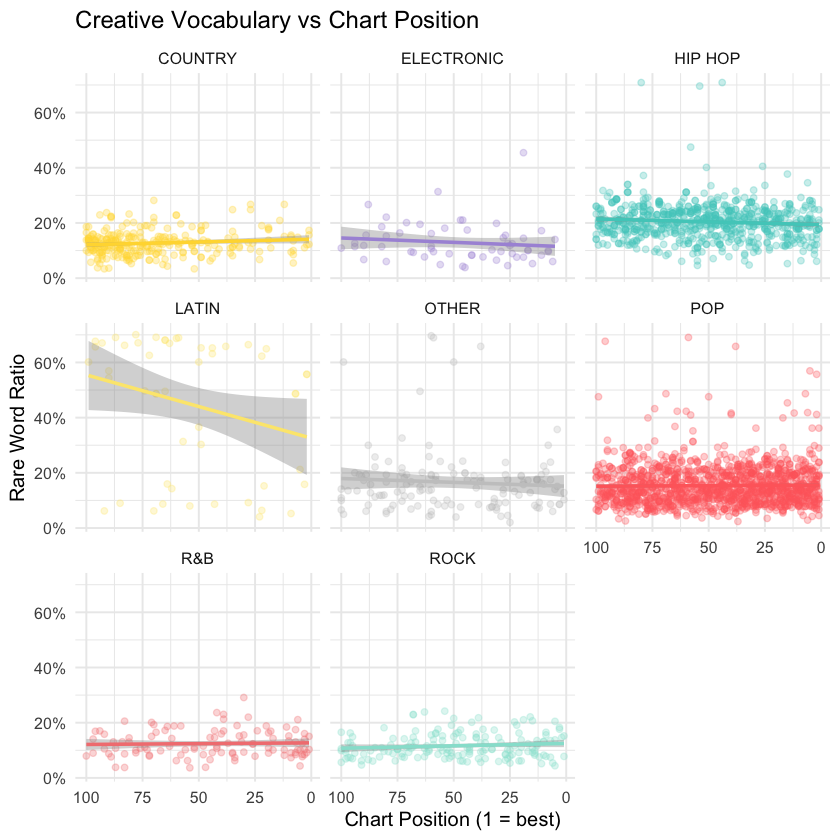

In [50]:
# Rare word ratio vs chart position (Creative Vocabulary vs Chart Position)
# X-axis reversed: 1 (best) on left, 100 on right
cor_rare <- cor.test(df_analysis$rare_word_ratio, df_analysis$ranking, method = "spearman")
cat(sprintf("Rare words vs Ranking: rho = %.3f, p = %.4f\n", cor_rare$estimate, cor_rare$p.value))

ggplot(df_analysis, aes(x = ranking, y = rare_word_ratio, color = macro_genre)) +
  geom_point(alpha = 0.3, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE, linewidth = 1) +
  scale_color_manual(values = genre_colors) +
  scale_x_reverse(limits = c(100, 1)) +
  scale_y_continuous(labels = percent_format()) +
  facet_wrap(~macro_genre, ncol = 3) +
  labs(title = "Creative Vocabulary vs Chart Position", 
       x = "Chart Position (1 = best)", 
       y = "Rare Word Ratio") +
  theme(legend.position = "none")

### Compression Ratio

Compression Ratio = gzip compressed size / original size

- Lower = more repetitive (compresses better)
- Higher = less repetitive

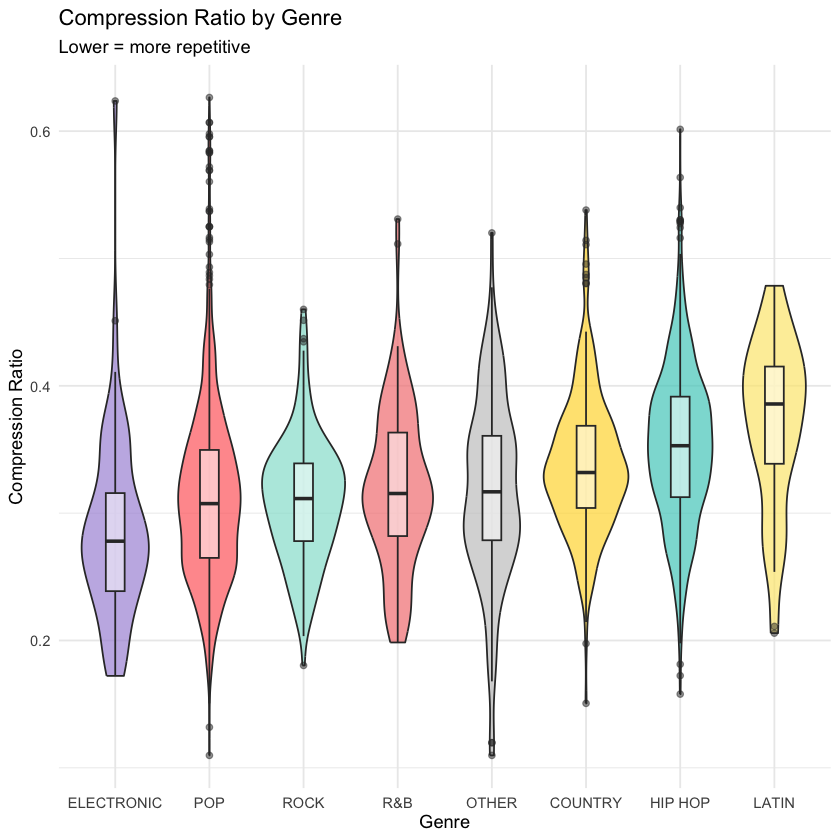

In [51]:
# Compression ratio by genre
ggplot(df_analysis, aes(x = reorder(macro_genre, compression_ratio, median), 
                        y = compression_ratio, 
                        fill = macro_genre)) +
  geom_violin(alpha = 0.7) +
  geom_boxplot(width = 0.2, fill = "white", alpha = 0.5) +
  scale_fill_manual(values = genre_colors) +
  labs(
    title = "Compression Ratio by Genre",
    subtitle = "Lower = more repetitive",
    x = "Genre",
    y = "Compression Ratio"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

`geom_smooth()` using formula = 'y ~ x'
Warning message in cor.test.default(df_analysis$compression_ratio, df_analysis$year, :
"Cannot compute exact p-value with ties"


Compression vs Year: rho = 0.027, p = 0.1540


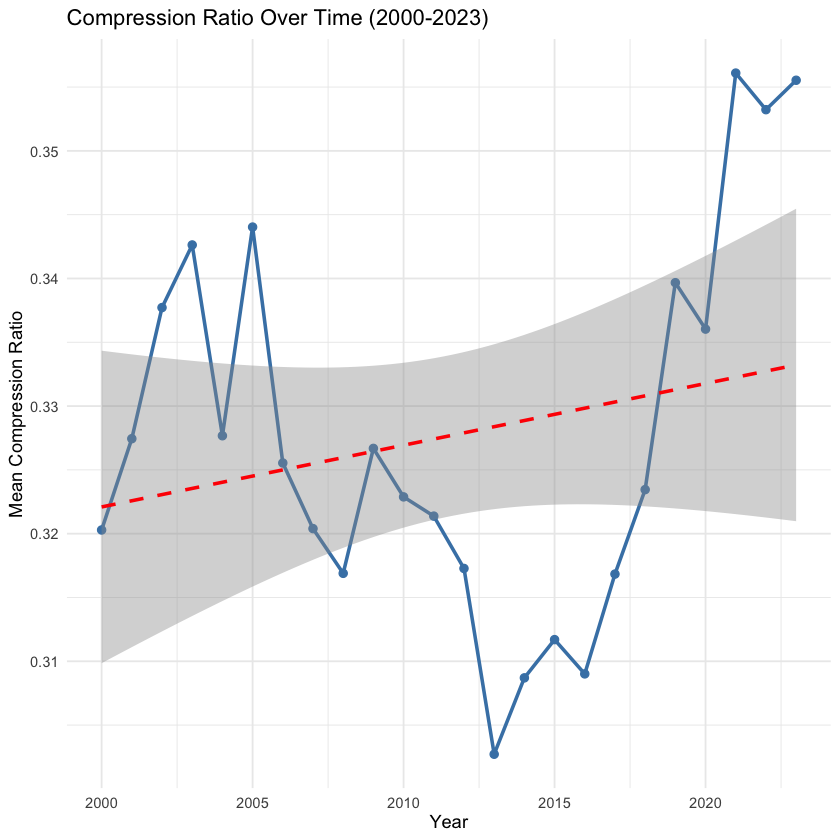

In [52]:
# Compression ratio over time
compression_trends <- df_analysis %>%
  group_by(year) %>%
  summarise(
    mean_compression = mean(compression_ratio, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(compression_trends, aes(x = year, y = mean_compression)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red", linetype = "dashed") +
  labs(
    title = "Compression Ratio Over Time (2000-2023)",
    x = "Year",
    y = "Mean Compression Ratio"
  ) +
  theme_minimal()

cor_compression_year <- cor.test(df_analysis$compression_ratio, df_analysis$year, method = "spearman")
cat(sprintf("Compression vs Year: rho = %.3f, p = %.4f\n", 
            cor_compression_year$estimate, cor_compression_year$p.value))

## 5. Vocabulary Uniqueness

How much do songs use common vs rare/creative words?

In [53]:
# Jaccard similarity summary
cat("Jaccard Common (overlap with 10k English words):\n")
summary(df_analysis$jaccard_common)

cat("\nRare Word Ratio (words NOT in common 10k):\n")
summary(df_analysis$rare_word_ratio)

Jaccard Common (overlap with 10k English words):


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0009005 0.0088982 0.0112949 0.0121963 0.0150228 0.0309421 


Rare Word Ratio (words NOT in common 10k):


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.02041 0.10791 0.15116 0.16594 0.20419 0.70874 

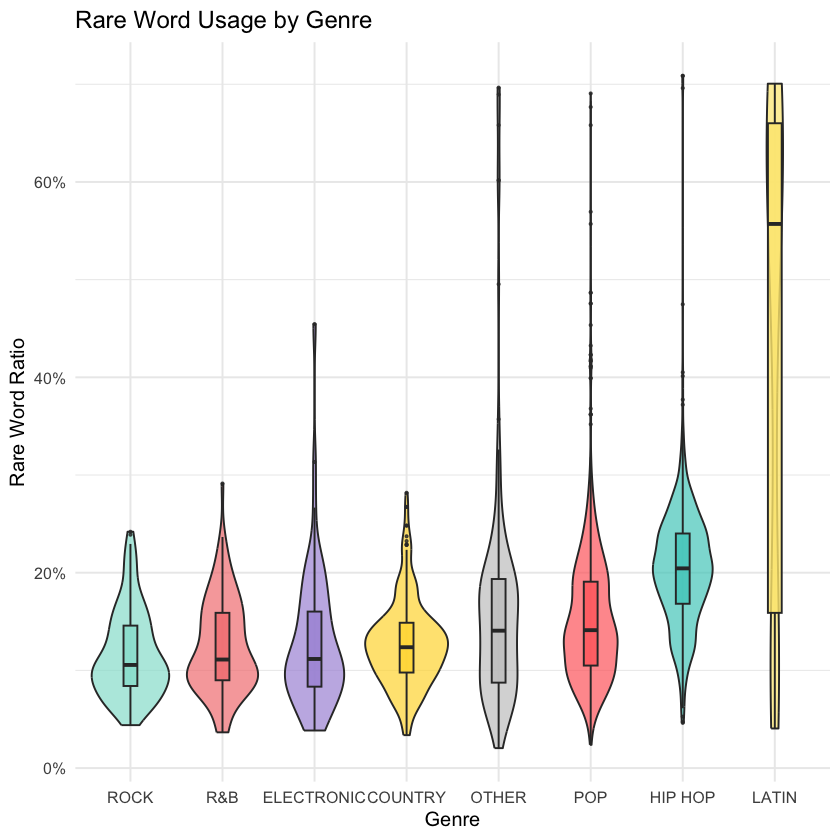

In [54]:
# Rare word ratio by genre
ggplot(df_analysis, aes(x = reorder(macro_genre, rare_word_ratio, median), 
                        y = rare_word_ratio, 
                        fill = macro_genre)) +
  geom_violin(alpha = 0.7) +
  geom_boxplot(width = 0.15, alpha = 0.8, outlier.size = 0.5) +
  scale_fill_manual(values = genre_colors) +
  scale_y_continuous(labels = percent_format()) +
  labs(title = "Rare Word Usage by Genre", x = "Genre", y = "Rare Word Ratio") +
  theme(legend.position = "none")

`geom_smooth()` using formula = 'y ~ x'


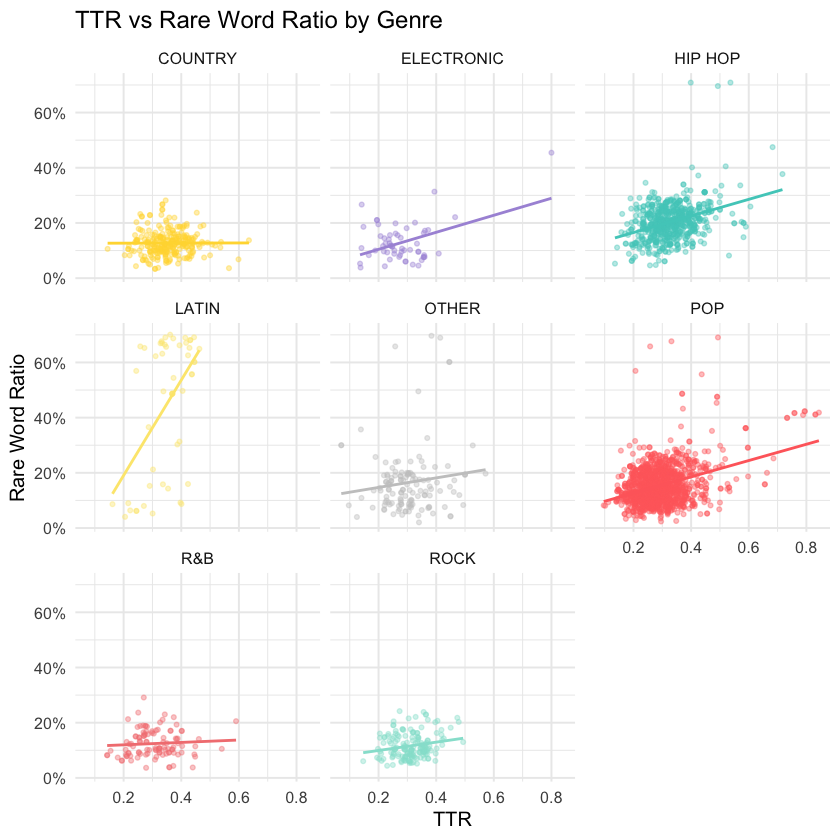

In [55]:
# TTR vs rare word ratio by genre
ggplot(df_analysis, aes(x = ttr, y = rare_word_ratio, color = macro_genre)) +
  geom_point(alpha = 0.4, size = 1) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  scale_color_manual(values = genre_colors) +
  facet_wrap(~macro_genre, ncol = 3) +
  scale_y_continuous(labels = percent_format()) +
  labs(title = "TTR vs Rare Word Ratio by Genre", x = "TTR", y = "Rare Word Ratio") +
  theme(legend.position = "none")

`geom_smooth()` using formula = 'y ~ x'
Warning message in cor.test.default(df_analysis$ttr, df_analysis$rare_word_ratio, :
"Cannot compute exact p-value with ties"



	Spearman's rank correlation rho

data:  df_analysis$ttr and df_analysis$rare_word_ratio
S = 2885785596, p-value < 0.00000000000000022
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.2295502 


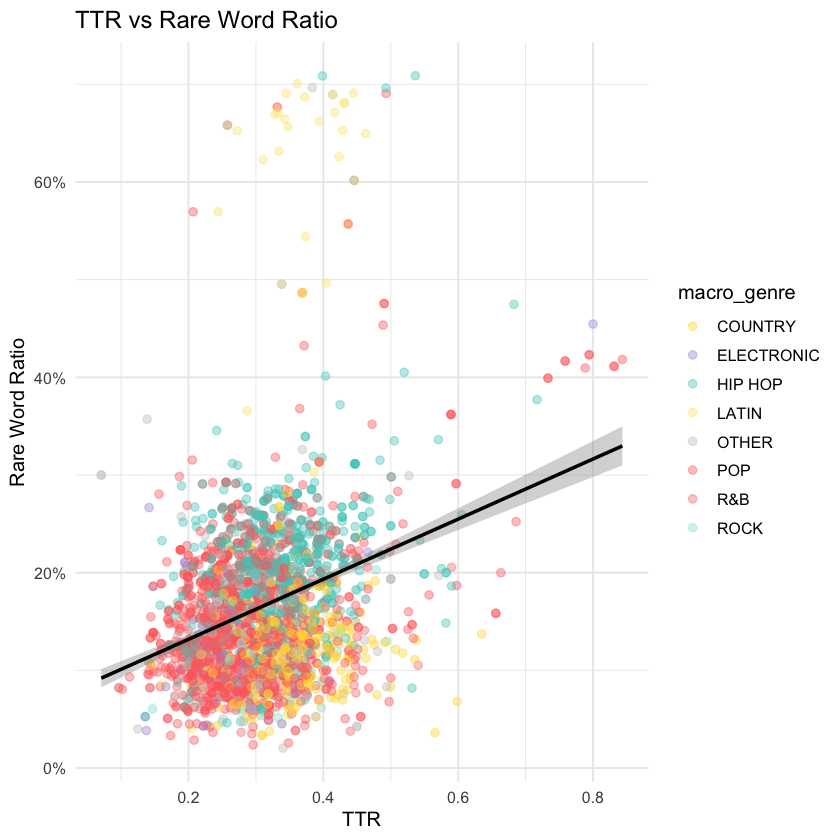

In [56]:
# TTR vs rare word ratio correlation
ggplot(df_analysis, aes(x = ttr, y = rare_word_ratio, color = macro_genre)) +
  geom_point(alpha = 0.4, size = 2) +
  geom_smooth(method = "lm", se = TRUE, color = "black", linewidth = 1) +
  scale_color_manual(values = genre_colors) +
  scale_y_continuous(labels = percent_format()) +
  labs(title = "TTR vs Rare Word Ratio", x = "TTR", y = "Rare Word Ratio") +
  theme(legend.position = "right")

cor.test(df_analysis$ttr, df_analysis$rare_word_ratio, method = "spearman")

## 6. Temporal Trends

`geom_smooth()` using formula = 'y ~ x'
Warning message in cor.test.default(df_analysis$ttr, df_analysis$year, method = "spearman"):
"Cannot compute exact p-value with ties"


TTR vs Year (all genres): rho = 0.064, p = 0.0007


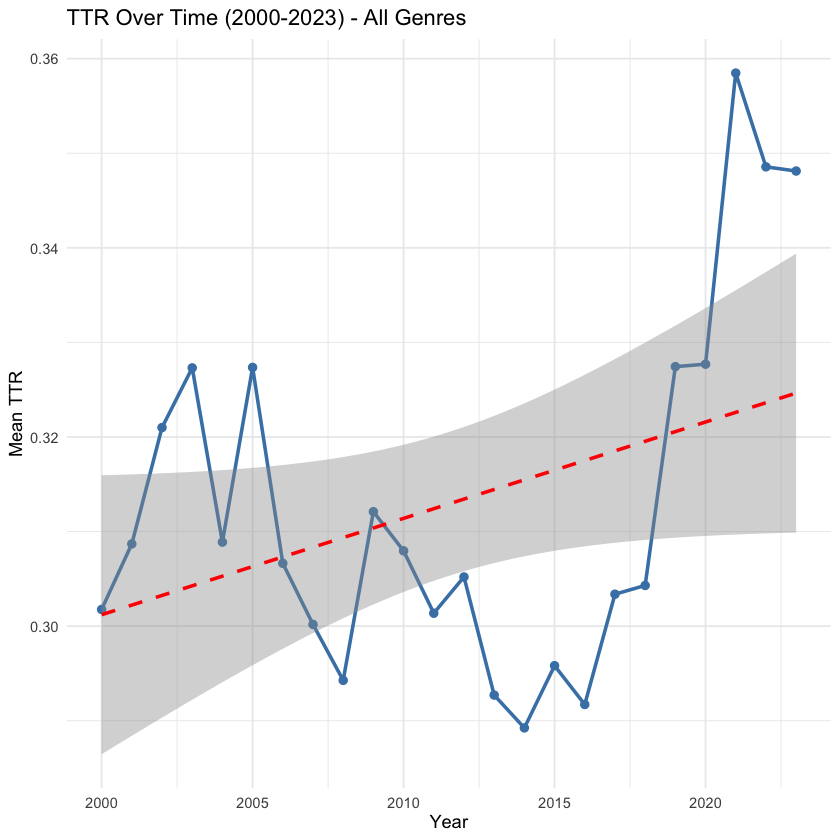

In [57]:
# TTR trends over time (overall)
yearly_trends <- df_analysis %>%
  group_by(year) %>%
  summarise(
    mean_ttr = mean(ttr, na.rm = TRUE),
    median_ttr = median(ttr, na.rm = TRUE),
    mean_rare = mean(rare_word_ratio, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(yearly_trends, aes(x = year, y = mean_ttr)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red", linetype = "dashed") +
  labs(title = "TTR Over Time (2000-2023) - All Genres", x = "Year", y = "Mean TTR") +
  theme_minimal()

cor_ttr_year <- cor.test(df_analysis$ttr, df_analysis$year, method = "spearman")
cat(sprintf("TTR vs Year (all genres): rho = %.3f, p = %.4f\n", cor_ttr_year$estimate, cor_ttr_year$p.value))

`geom_smooth()` using formula = 'y ~ x'


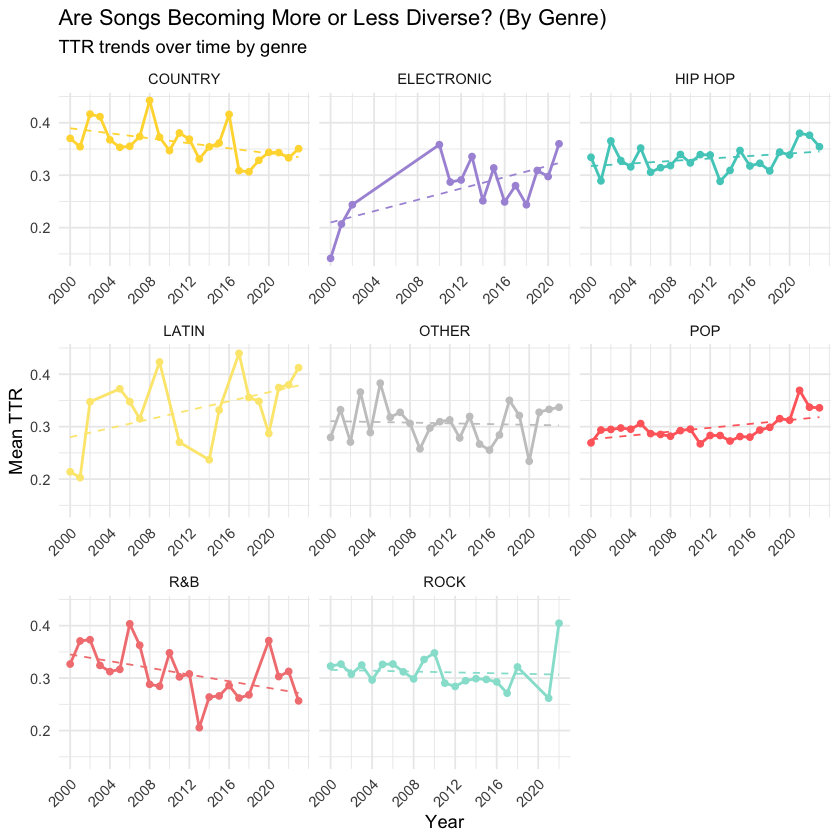

In [58]:
# TTR trends over time BY GENRE
yearly_trends_genre <- df_analysis %>%
  group_by(year, macro_genre) %>%
  summarise(
    mean_ttr = mean(ttr, na.rm = TRUE),
    n = n(),
    .groups = "drop"
  )

ggplot(yearly_trends_genre, aes(x = year, y = mean_ttr, color = macro_genre)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed", linewidth = 0.5) +
  scale_color_manual(values = genre_colors) +
  scale_x_continuous(breaks = seq(2000, 2023, by = 4)) +
  facet_wrap(~macro_genre, ncol = 3, scales = "free_x") +
  labs(title = "Are Songs Becoming More or Less Diverse? (By Genre)", 
       subtitle = "TTR trends over time by genre",
       x = "Year", 
       y = "Mean TTR") +
  theme_minimal() +
  theme(legend.position = "none",
        axis.text.x = element_text(angle = 45, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message in cor.test.default(df_analysis$rare_word_ratio, df_analysis$year, :
"Cannot compute exact p-value with ties"


Rare words vs Year (all genres): rho = 0.128, p = 0.0000


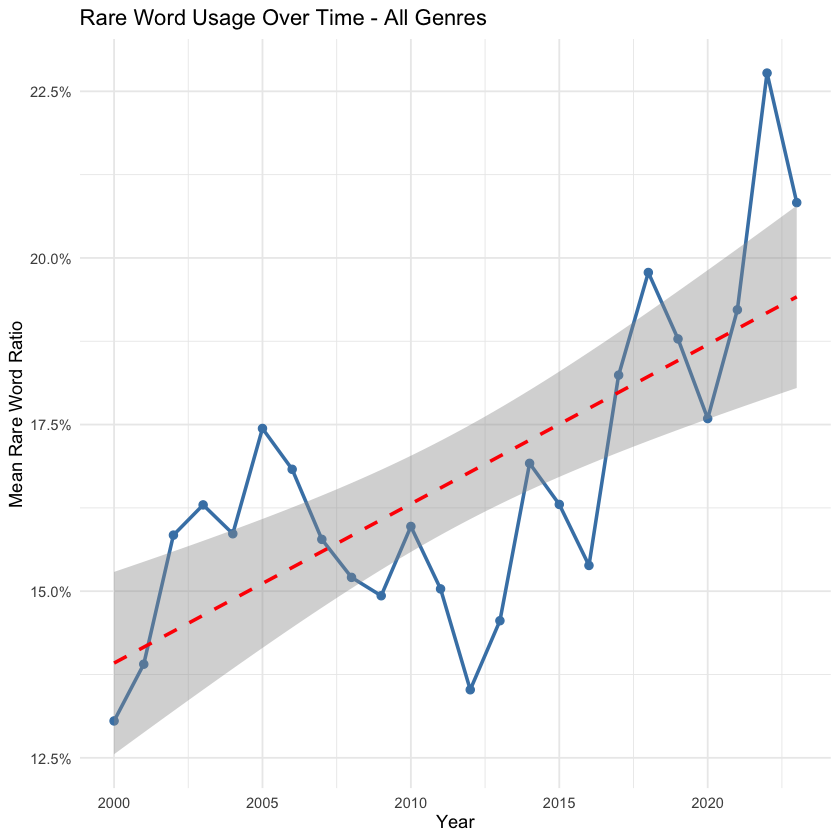

In [59]:
# Rare word ratio over time (overall)
ggplot(yearly_trends, aes(x = year, y = mean_rare)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red", linetype = "dashed") +
  scale_y_continuous(labels = percent_format()) +
  labs(title = "Rare Word Usage Over Time - All Genres", x = "Year", y = "Mean Rare Word Ratio") +
  theme_minimal()

cor_rare_year <- cor.test(df_analysis$rare_word_ratio, df_analysis$year, method = "spearman")
cat(sprintf("Rare words vs Year (all genres): rho = %.3f, p = %.4f\n", cor_rare_year$estimate, cor_rare_year$p.value))

`geom_smooth()` using formula = 'y ~ x'


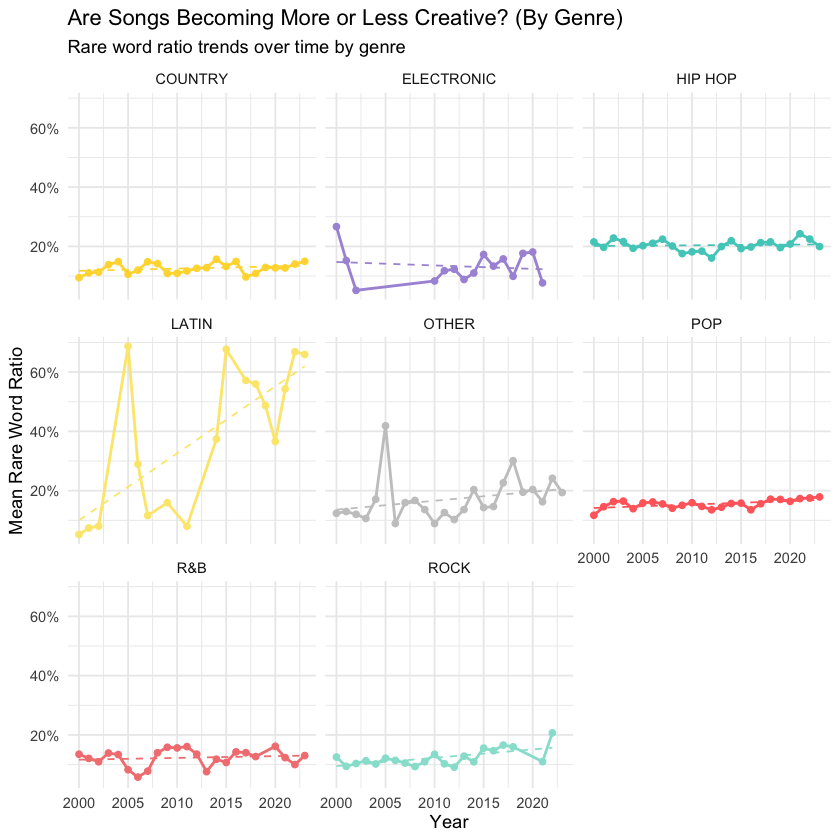

In [60]:
# Rare word ratio over time BY GENRE
yearly_rare_genre <- df_analysis %>%
  group_by(year, macro_genre) %>%
  summarise(
    mean_rare = mean(rare_word_ratio, na.rm = TRUE),
    n = n(),
    .groups = "drop"
  )

ggplot(yearly_rare_genre, aes(x = year, y = mean_rare, color = macro_genre)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed", linewidth = 0.5) +
  scale_color_manual(values = genre_colors) +
  scale_y_continuous(labels = percent_format()) +
  facet_wrap(~macro_genre, ncol = 3) +
  labs(title = "Are Songs Becoming More or Less Creative? (By Genre)", 
       subtitle = "Rare word ratio trends over time by genre",
       x = "Year", 
       y = "Mean Rare Word Ratio") +
  theme_minimal() +
  theme(legend.position = "none")

## 7. Key Findings

In [61]:
# Most and least diverse songs
cat("=== HIGHEST TTR ===\n")
df_analysis %>%
  select(song, band_singer, year, macro_genre, ttr, total_words) %>%
  arrange(desc(ttr)) %>%
  head(10)

cat("\n=== LOWEST TTR ===\n")
df_analysis %>%
  select(song, band_singer, year, macro_genre, ttr, total_words) %>%
  arrange(ttr) %>%
  head(10)

=== HIGHEST TTR ===


song,band_singer,year,macro_genre,ttr,total_words
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
Calm Down,Selena Gomez,2023,POP,0.8434579,428
Save Your Tears,Ariana Grande,2021,POP,0.8311966,468
Save Your Tears,Ariana Grande,2022,POP,0.8311966,468
Where Are <U+00DC> Now,Jack <U+00DC>,2015,ELECTRONIC,0.8000000,220
Essence,Justin Bieber,2021,POP,0.7942974,491
Essence,Justin Bieber,2022,POP,0.7942974,491
Meet Me Halfway,The Black Eyed Peas,2010,POP,0.7884187,449
I Hope,Charlie Puth,2020,POP,0.7586207,174
I Hope,Charlie Puth,2021,POP,0.7586207,174



=== LOWEST TTR ===


song,band_singer,year,macro_genre,ttr,total_words
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
Watch Me,Silent<U+00F3>,2015,OTHER,0.07058824,425
Watch Me,Silent<U+00F3>,2016,OTHER,0.07058824,425
Get Lucky,Daft Punk,2013,OTHER,0.09668874,755
Get Lucky,Pharrell Williams,2013,POP,0.09668874,755
Gold,Kiiara,2016,POP,0.10163934,610
Turn Up the Music,Chris Brown,2012,POP,0.11261261,666
Blue (Da Ba Dee),Eiffel 65,2000,OTHER,0.12479201,601
Turn Down for What,DJ Snake,2014,ELECTRONIC,0.13571429,140
Turn Down for What,Lil Jon,2014,HIP HOP,0.13571429,140


## 8. Artist Vocabulary Rankings

Which artists have the largest vocabularies across their charting songs?

In [62]:
# Artist vocabulary analysis
library(tidytext)

df_full <- read_csv('../../data/cleaned/billboard_lexical_analysis_ready.csv', show_col_types = FALSE)

tokens <- df_full %>%
  filter(!is.na(lyrics)) %>%
  select(song, band_singer, year, lyrics, macro_genre) %>%
  unnest_tokens(word, lyrics) %>%
  mutate(word = str_replace_all(word, "[^a-z]", "")) %>%
  filter(word != "")

artist_vocab <- tokens %>%
  group_by(band_singer) %>%
  summarise(
    total_words = n(),
    unique_words = n_distinct(word),
    songs = n_distinct(song),
    .groups = "drop"
  ) %>%
  filter(songs >= 5) %>%
  arrange(desc(unique_words))

cat(sprintf("Artists with 5+ songs: %d\n", nrow(artist_vocab)))
head(artist_vocab, 20)

Artists with 5+ songs: 161


band_singer,total_words,unique_words,songs
<chr>,<int>,<int>,<int>
Drake,42094,3674,63
Destiny's Child,27227,3018,8
Lil Wayne,23768,2945,32
Kanye West,16508,2598,22
Eminem,18268,2566,20
Nicki Minaj,21042,2362,30
The Black Eyed Peas,8233,2306,13
Ludacris,19127,2243,26
Camila Cabello,7758,2129,8


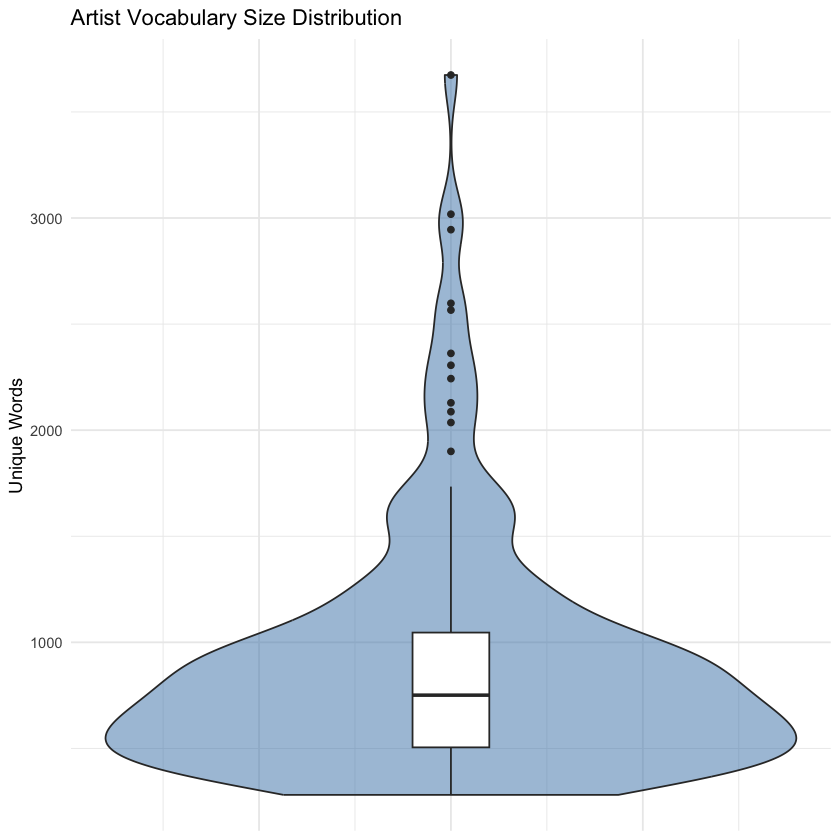

In [63]:
# Artist vocabulary distribution
ggplot(artist_vocab, aes(x = 1, y = unique_words)) +
  geom_violin(fill = "steelblue", alpha = 0.5) +
  geom_boxplot(width = 0.1) +
  labs(title = "Artist Vocabulary Size Distribution", y = "Unique Words") +
  theme_minimal() +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank())

In [64]:
# Drake vs other top artists
drake_stats <- artist_vocab %>%
  filter(str_detect(str_to_lower(band_singer), "drake"))

cat("Drake's vocabulary stats:\n")
print(drake_stats)

cat(sprintf("\nDrake's percentile: %.1f%%\n", 
            mean(artist_vocab$unique_words <= drake_stats$unique_words[1]) * 100))

Drake's vocabulary stats:
# A tibble: 1 x 4
  band_singer total_words unique_words songs
  <chr>             <int>        <int> <int>
1 Drake             42094         3674    63

Drake's percentile: 100.0%


## 9. Lexical Density

Lexical Density = Content Words / Total Words

- High: More meaningful content (nouns, verbs, adjectives)
- Low: More function words (the, a, is, and)

In [65]:
# Lexical density overview
cat("Lexical Density Summary:\n")
summary(df_analysis$lexical_density)

cat(sprintf("\nCorrelation with TTR: %.3f\n", 
            cor(df_analysis$lexical_density, df_analysis$ttr, use = "complete.obs")))

Lexical Density Summary:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.07129 0.30756 0.36200 0.37477 0.42465 0.95368 


Correlation with TTR: 0.262


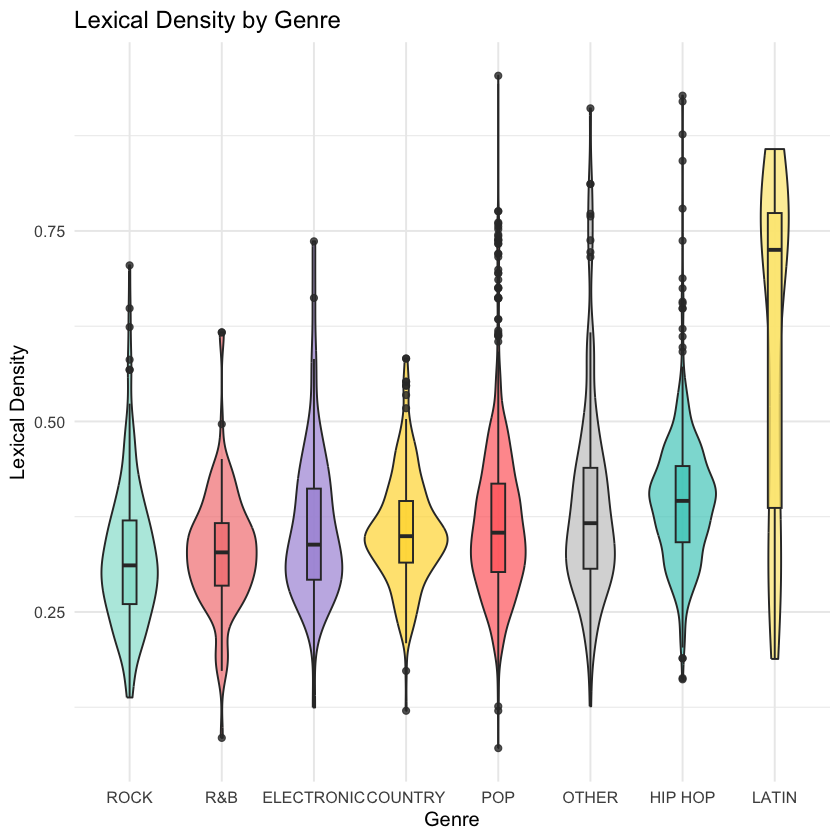

In [66]:
# Lexical density by genre
ggplot(df_analysis, aes(x = reorder(macro_genre, lexical_density, median), 
                        y = lexical_density, 
                        fill = macro_genre)) +
  geom_violin(alpha = 0.7) +
  geom_boxplot(width = 0.15, alpha = 0.8) +
  scale_fill_manual(values = genre_colors) +
  labs(title = "Lexical Density by Genre", x = "Genre", y = "Lexical Density") +
  theme(legend.position = "none")

In [67]:
# Lexical density vs chart position
cor.test(df_analysis$lexical_density, df_analysis$ranking, method = "spearman")

Warning message in cor.test.default(df_analysis$lexical_density, df_analysis$ranking, :
"Cannot compute exact p-value with ties"



	Spearman's rank correlation rho

data:  df_analysis$lexical_density and df_analysis$ranking
S = 3709858134, p-value = 0.6125
alternative hypothesis: true rho is not equal to 0
sample estimates:
        rho 
0.009538545 


`geom_smooth()` using formula = 'y ~ x'


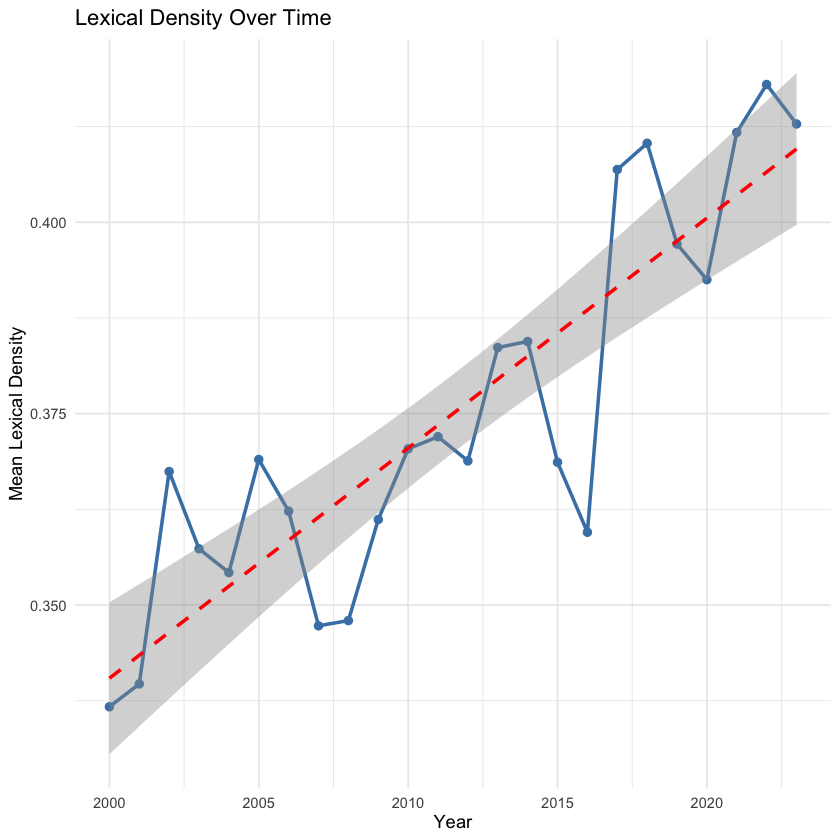

In [68]:
# Lexical density over time
lex_trends <- df_analysis %>%
  group_by(year) %>%
  summarise(mean_lex = mean(lexical_density, na.rm = TRUE), .groups = "drop")

ggplot(lex_trends, aes(x = year, y = mean_lex)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red", linetype = "dashed") +
  labs(title = "Lexical Density Over Time", x = "Year", y = "Mean Lexical Density") +
  theme_minimal()

In [69]:
# Jaccard similarity vs chart position
cor_genre <- cor.test(df_analysis$jaccard_genre, df_analysis$ranking, method = "spearman")
cat(sprintf("Jaccard genre vs Ranking: rho = %.3f, p = %.4f\n", cor_genre$estimate, cor_genre$p.value))

Warning message in cor.test.default(df_analysis$jaccard_genre, df_analysis$ranking, :
"Cannot compute exact p-value with ties"


Jaccard genre vs Ranking: rho = -0.019, p = 0.3214


In [70]:
# Most and least substantive songs
cat("=== HIGHEST LEXICAL DENSITY ===\n")
df_analysis %>%
  select(song, band_singer, year, macro_genre, lexical_density) %>%
  arrange(desc(lexical_density)) %>%
  head(10)

cat("\n=== LOWEST LEXICAL DENSITY ===\n")
df_analysis %>%
  select(song, band_singer, year, macro_genre, lexical_density) %>%
  arrange(lexical_density) %>%
  head(10)

=== HIGHEST LEXICAL DENSITY ===


song,band_singer,year,macro_genre,lexical_density
<chr>,<chr>,<dbl>,<chr>,<dbl>
Bad,Rihanna,2013,POP,0.9536785
Hot Boy,Bobby Shmurda,2014,HIP HOP,0.9275362
Thugz Mansion,2Pac,2003,HIP HOP,0.9198397
Harlem Shake,Baauer,2013,OTHER,0.9108911
Locked Up,Styles P,2004,HIP HOP,0.8767361
Dura,Daddy Yankee,2018,LATIN,0.8574181
Despu<U+00E9>s de la Playa,Bad Bunny,2022,LATIN,0.8506494
No More Parties,Lil Durk,2021,HIP HOP,0.8419689
Party,Bad Bunny,2022,LATIN,0.8299817



=== LOWEST LEXICAL DENSITY ===


song,band_singer,year,macro_genre,lexical_density
<chr>,<chr>,<dbl>,<chr>,<dbl>
Down,Marian Hill,2017,POP,0.07129094
Say,John Mayer,2008,R&B,0.08474576
Say Something,Justin Timberlake,2018,POP,0.12035011
Say Something,Chris Stapleton,2018,COUNTRY,0.12035011
Where Are <U+00DC> Now,Skrillex,2015,ELECTRONIC,0.12463768
Where Are <U+00DC> Now,Diplo,2015,OTHER,0.12618297
Where Are <U+00DC> Now,Justin Bieber,2015,POP,0.12618297
Paris,The Chainsmokers,2017,POP,0.13221154
When It's Over,Sugar Ray,2001,ROCK,0.13777778


## 10. Jaccard Similarity

Measures vocabulary overlap: |A ∩ B| / |A ∪ B|

- **jaccard_genre**: How typical for genre (higher = more typical)
- **jaccard_corpus**: How mainstream (higher = common Billboard vocabulary)

In [71]:
# Jaccard metrics by genre
jaccard_by_genre <- df_analysis %>%
  group_by(macro_genre) %>%
  summarise(
    mean_jaccard_genre = mean(jaccard_genre, na.rm = TRUE),
    mean_jaccard_corpus = mean(jaccard_corpus, na.rm = TRUE),
    .groups = "drop"
  )
print(jaccard_by_genre)

# A tibble: 8 x 3
  macro_genre mean_jaccard_genre mean_jaccard_corpus
  <chr>                    <dbl>               <dbl>
1 COUNTRY                  0.155              0.0884
2 ELECTRONIC               0.132              0.0743
3 HIP HOP                  0.204              0.132 
4 LATIN                    0.154              0.0692
5 OTHER                    0.148              0.0927
6 POP                      0.171              0.105 
7 R&B                      0.167              0.0965
8 ROCK                     0.142              0.0804


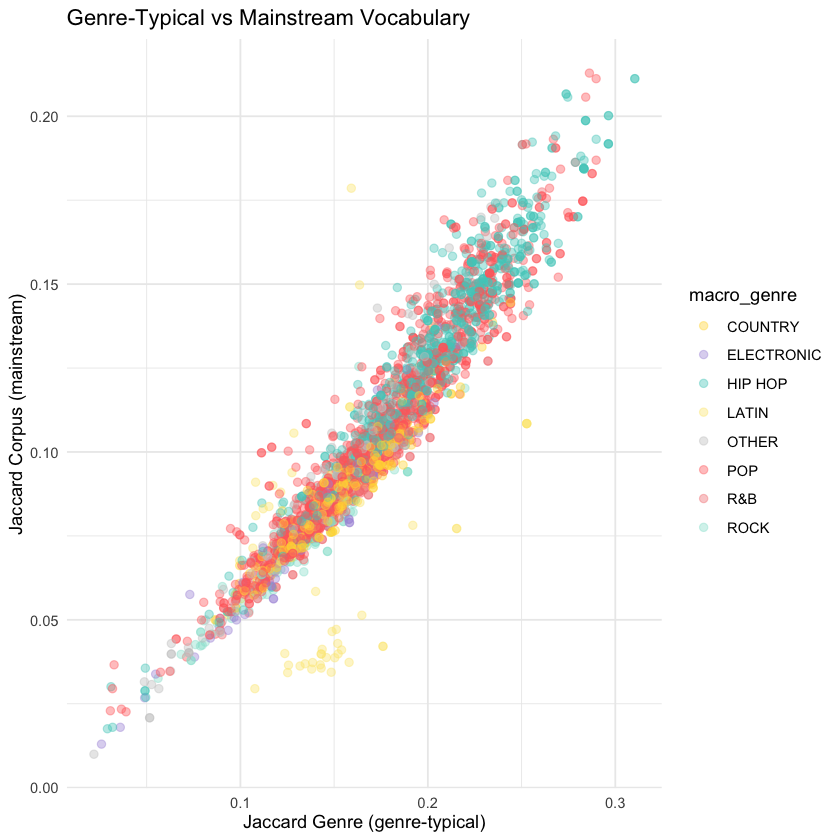

In [72]:
# Jaccard 2D space: genre-typical vs mainstream
ggplot(df_analysis, aes(x = jaccard_genre, y = jaccard_corpus, color = macro_genre)) +
  geom_point(alpha = 0.4, size = 2) +
  scale_color_manual(values = genre_colors) +
  labs(title = "Genre-Typical vs Mainstream Vocabulary", 
       x = "Jaccard Genre (genre-typical)", 
       y = "Jaccard Corpus (mainstream)") +
  theme_minimal()

In [73]:
# Jaccard corpus vs chart position
cor_corpus <- cor.test(df_analysis$jaccard_corpus, df_analysis$ranking, method = "spearman")
cat(sprintf("Jaccard corpus vs Ranking: rho = %.3f, p = %.4f\n", cor_corpus$estimate, cor_corpus$p.value))

Warning message in cor.test.default(df_analysis$jaccard_corpus, df_analysis$ranking, :
"Cannot compute exact p-value with ties"


Jaccard corpus vs Ranking: rho = -0.017, p = 0.3651


`geom_smooth()` using formula = 'y ~ x'


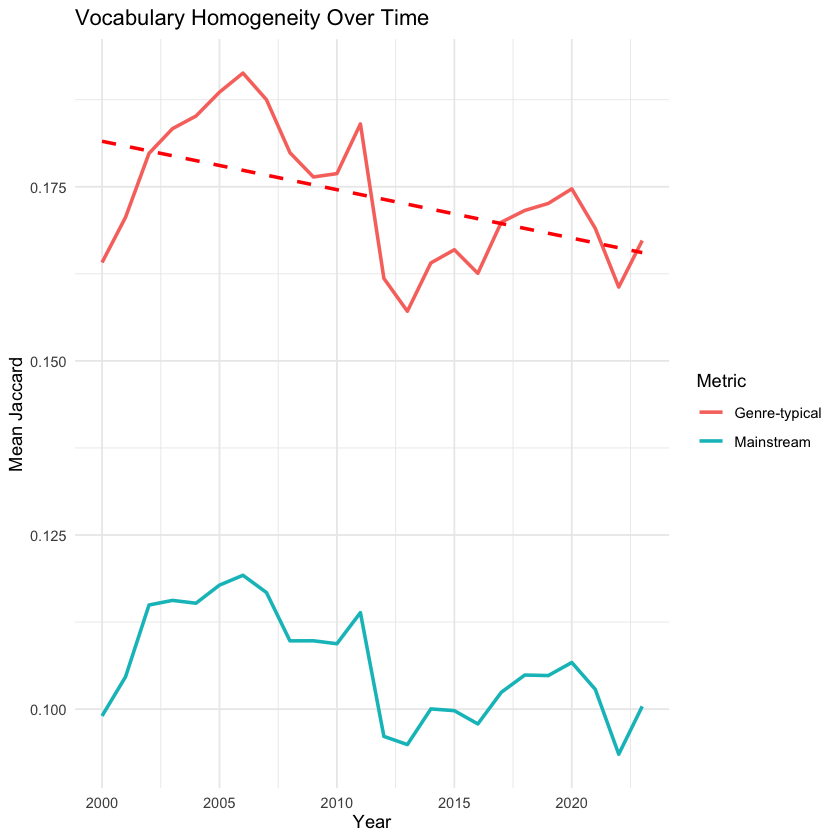

In [74]:
# Jaccard trends over time
jaccard_trends <- df_analysis %>%
  group_by(year) %>%
  summarise(
    mean_genre = mean(jaccard_genre, na.rm = TRUE),
    mean_corpus = mean(jaccard_corpus, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(jaccard_trends, aes(x = year)) +
  geom_line(aes(y = mean_genre, color = "Genre-typical"), linewidth = 1) +
  geom_line(aes(y = mean_corpus, color = "Mainstream"), linewidth = 1) +
  geom_smooth(aes(y = mean_genre), method = "lm", se = FALSE, linetype = "dashed", color = "red") +
  labs(title = "Vocabulary Homogeneity Over Time", x = "Year", y = "Mean Jaccard", color = "Metric") +
  theme_minimal()

In [75]:
# Genre outliers
cat("=== MOST GENRE-TYPICAL ===\n")
df_analysis %>%
  filter(!is.na(jaccard_genre)) %>%
  select(song, band_singer, macro_genre, jaccard_genre) %>%
  arrange(desc(jaccard_genre)) %>%
  head(10)

cat("\n=== LEAST GENRE-TYPICAL ===\n")
df_analysis %>%
  filter(!is.na(jaccard_genre)) %>%
  select(song, band_singer, macro_genre, jaccard_genre) %>%
  arrange(jaccard_genre) %>%
  head(10)

=== MOST GENRE-TYPICAL ===


song,band_singer,macro_genre,jaccard_genre
<chr>,<chr>,<chr>,<dbl>
Look at Me Now,Lil Wayne,HIP HOP,0.3104000
Look at Me Now,Busta Rhymes,HIP HOP,0.3104000
Shake That,Eminem,HIP HOP,0.2963576
Shake That,Nate Dogg,HIP HOP,0.2963576
Lifestyle,Rich Gang,HIP HOP,0.2962963
Lifestyle,Young Thug,HIP HOP,0.2962963
Lifestyle,Rich Homie Quan,HIP HOP,0.2962963
Gossip Folks,Ludacris,HIP HOP,0.2897898
Love the Way You Lie,Rihanna,POP,0.2897822



=== LEAST GENRE-TYPICAL ===


song,band_singer,macro_genre,jaccard_genre
<chr>,<chr>,<chr>,<dbl>
Harlem Shake,Baauer,OTHER,0.02186879
Better Off Alone,Alice Deejay,ELECTRONIC,0.02589641
Hot Boy,Bobby Shmurda,HIP HOP,0.02905983
OMG,will.i.am,POP,0.03063063
Thugz Mansion,2Pac,HIP HOP,0.03097345
Bailando,Enrique Iglesias,POP,0.03177258
Turn Down for What,Lil Jon,HIP HOP,0.03180915
El Perd<U+00F3>n,Enrique Iglesias,POP,0.03262643
Turn Down for What,DJ Snake,ELECTRONIC,0.03592814


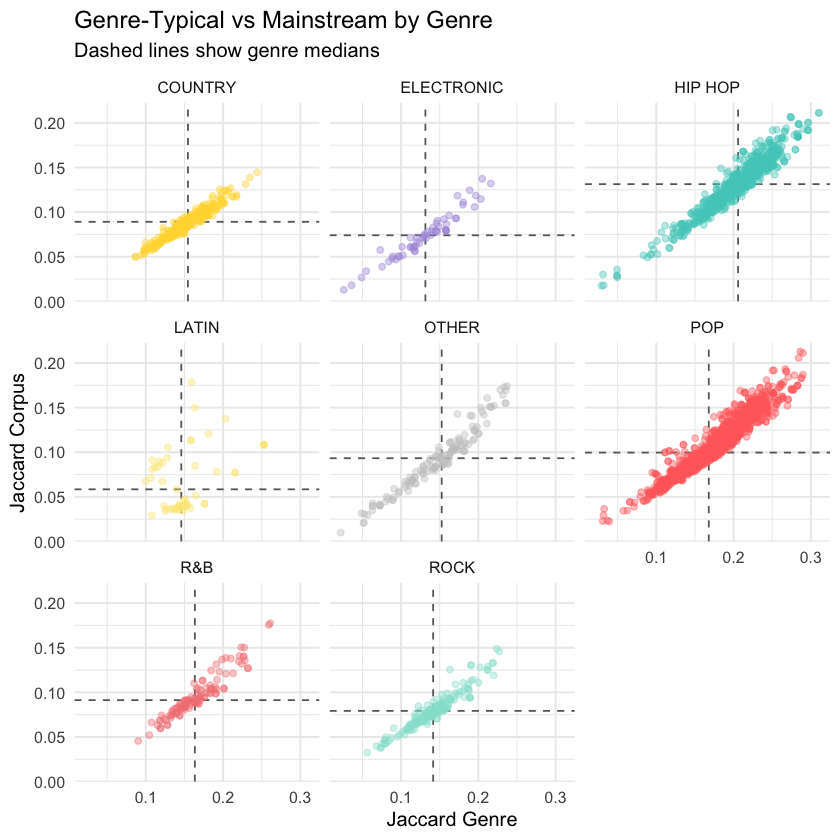

In [76]:
# Jaccard by genre faceted with median reference lines
jaccard_medians <- df_analysis %>%
  group_by(macro_genre) %>%
  summarise(
    median_jaccard_genre = median(jaccard_genre, na.rm = TRUE),
    median_jaccard_corpus = median(jaccard_corpus, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(df_analysis, aes(x = jaccard_genre, y = jaccard_corpus)) +
  geom_vline(data = jaccard_medians, aes(xintercept = median_jaccard_genre),
             linetype = "dashed", color = "gray40", linewidth = 0.5) +
  geom_hline(data = jaccard_medians, aes(yintercept = median_jaccard_corpus),
             linetype = "dashed", color = "gray40", linewidth = 0.5) +
  geom_point(aes(color = macro_genre), alpha = 0.4, size = 1.5) +
  scale_color_manual(values = genre_colors) +
  facet_wrap(~macro_genre, ncol = 3) +
  labs(title = "Genre-Typical vs Mainstream by Genre",
       subtitle = "Dashed lines show genre medians",
       x = "Jaccard Genre", y = "Jaccard Corpus") +
  theme(legend.position = "none")

## 11. Export Visualizations

Save all plots to the output folder.

In [77]:
# Export all visualizations to outputs/lexical_analysis/
output_dir <- '../../outputs/lexical_analysis'
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

# 1. TTR Distribution by Genre
p1 <- ggplot(df_analysis, aes(x = reorder(macro_genre, ttr, median), y = ttr, fill = macro_genre)) +
  geom_violin(alpha = 0.7, draw_quantiles = c(0.25, 0.5, 0.75)) +
  geom_jitter(alpha = 0.1, width = 0.2, size = 0.5) +
  scale_fill_manual(values = genre_colors) +
  labs(title = "TTR Distribution by Genre", x = "Genre", y = "TTR") +
  coord_flip() +
  theme(legend.position = "none")
ggsave(file.path(output_dir, '01_ttr_by_genre.png'), p1, width = 10, height = 6, dpi = 300, bg = 'white')

# 2. Average TTR by Genre
p2 <- ggplot(genre_rankings, aes(x = reorder(macro_genre, mean_ttr), y = mean_ttr, fill = macro_genre)) +
  geom_col() +
  geom_text(aes(label = sprintf("%.3f", mean_ttr)), hjust = -0.2, size = 4) +
  scale_fill_manual(values = genre_colors) +
  labs(title = "Average TTR by Genre", x = "Genre", y = "TTR") +
  coord_flip() +
  theme(legend.position = "none")
ggsave(file.path(output_dir, '02_avg_ttr_by_genre.png'), p2, width = 10, height = 6, dpi = 300, bg = 'white')

# 3. TTR vs Chart Position by Genre
p3 <- ggplot(df_analysis, aes(x = ranking, y = ttr, color = macro_genre)) +
  geom_point(alpha = 0.3, size = 1.5) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  scale_color_manual(values = genre_colors) +
  scale_x_reverse(limits = c(100, 1)) +
  facet_wrap(~macro_genre, ncol = 3) +
  labs(title = "TTR vs Chart Position by Genre", x = "Chart Position (1 = best)", y = "TTR") +
  theme(legend.position = "none")
ggsave(file.path(output_dir, '03_ttr_vs_chart_position.png'), p3, width = 12, height = 8, dpi = 300, bg = 'white')

# 4. Creative Vocabulary vs Chart Position
p4 <- ggplot(df_analysis, aes(x = ranking, y = rare_word_ratio, color = macro_genre)) +
  geom_point(alpha = 0.3, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE, linewidth = 1) +
  scale_color_manual(values = genre_colors) +
  scale_x_reverse(limits = c(100, 1)) +
  scale_y_continuous(labels = percent_format()) +
  facet_wrap(~macro_genre, ncol = 3) +
  labs(title = "Creative Vocabulary vs Chart Position", x = "Chart Position (1 = best)", y = "Rare Word Ratio") +
  theme(legend.position = "none")
ggsave(file.path(output_dir, '04_creative_vocab_vs_chart.png'), p4, width = 12, height = 8, dpi = 300, bg = 'white')

# 5. Compression Ratio by Genre
p5 <- ggplot(df_analysis, aes(x = reorder(macro_genre, compression_ratio, median), y = compression_ratio, fill = macro_genre)) +
  geom_violin(alpha = 0.7) +
  geom_boxplot(width = 0.2, fill = "white", alpha = 0.5) +
  scale_fill_manual(values = genre_colors) +
  labs(title = "Compression Ratio by Genre", subtitle = "Lower = more repetitive", x = "Genre", y = "Compression Ratio") +
  theme_minimal() +
  theme(legend.position = "none")
ggsave(file.path(output_dir, '05_compression_by_genre.png'), p5, width = 10, height = 6, dpi = 300, bg = 'white')

# 6. Compression Ratio Over Time
p6 <- ggplot(compression_trends, aes(x = year, y = mean_compression)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red", linetype = "dashed") +
  labs(title = "Compression Ratio Over Time (2000-2023)", x = "Year", y = "Mean Compression Ratio") +
  theme_minimal()
ggsave(file.path(output_dir, '06_compression_over_time.png'), p6, width = 10, height = 6, dpi = 300, bg = 'white')

# 7. Rare Word Usage by Genre
p7 <- ggplot(df_analysis, aes(x = reorder(macro_genre, rare_word_ratio, median), y = rare_word_ratio, fill = macro_genre)) +
  geom_violin(alpha = 0.7) +
  geom_boxplot(width = 0.15, alpha = 0.8, outlier.size = 0.5) +
  scale_fill_manual(values = genre_colors) +
  scale_y_continuous(labels = percent_format()) +
  labs(title = "Rare Word Usage by Genre", x = "Genre", y = "Rare Word Ratio") +
  theme(legend.position = "none")
ggsave(file.path(output_dir, '07_rare_words_by_genre.png'), p7, width = 10, height = 6, dpi = 300, bg = 'white')

# 8. TTR vs Rare Word Ratio
p8 <- ggplot(df_analysis, aes(x = ttr, y = rare_word_ratio, color = macro_genre)) +
  geom_point(alpha = 0.4, size = 2) +
  geom_smooth(method = "lm", se = TRUE, color = "black", linewidth = 1) +
  scale_color_manual(values = genre_colors) +
  scale_y_continuous(labels = percent_format()) +
  labs(title = "TTR vs Rare Word Ratio", x = "TTR", y = "Rare Word Ratio") +
  theme(legend.position = "right")
ggsave(file.path(output_dir, '08_ttr_vs_rare_words.png'), p8, width = 10, height = 6, dpi = 300, bg = 'white')

# 9. TTR Over Time - All Genres
p9 <- ggplot(yearly_trends, aes(x = year, y = mean_ttr)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red", linetype = "dashed") +
  labs(title = "TTR Over Time (2000-2023) - All Genres", x = "Year", y = "Mean TTR") +
  theme_minimal()
ggsave(file.path(output_dir, '09_ttr_over_time.png'), p9, width = 10, height = 6, dpi = 300, bg = 'white')

# 10. TTR Over Time BY GENRE
p10 <- ggplot(yearly_trends_genre, aes(x = year, y = mean_ttr, color = macro_genre)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed", linewidth = 0.5) +
  scale_color_manual(values = genre_colors) +
  scale_x_continuous(breaks = seq(2000, 2023, by = 4)) +
  facet_wrap(~macro_genre, ncol = 3, scales = "free_x") +
  labs(title = "Are Songs Becoming More or Less Diverse? (By Genre)", subtitle = "TTR trends over time by genre", x = "Year", y = "Mean TTR") +
  theme_minimal() +
  theme(legend.position = "none",
        axis.text.x = element_text(angle = 45, hjust = 1))
ggsave(file.path(output_dir, '10_ttr_over_time_by_genre.png'), p10, width = 12, height = 8, dpi = 300, bg = 'white')

# 11. Rare Word Ratio Over Time - All Genres
p11 <- ggplot(yearly_trends, aes(x = year, y = mean_rare)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red", linetype = "dashed") +
  scale_y_continuous(labels = percent_format()) +
  labs(title = "Rare Word Usage Over Time - All Genres", x = "Year", y = "Mean Rare Word Ratio") +
  theme_minimal()
ggsave(file.path(output_dir, '11_rare_words_over_time.png'), p11, width = 10, height = 6, dpi = 300, bg = 'white')

# 12. Rare Word Ratio Over Time BY GENRE
p12 <- ggplot(yearly_rare_genre, aes(x = year, y = mean_rare, color = macro_genre)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed", linewidth = 0.5) +
  scale_color_manual(values = genre_colors) +
  scale_y_continuous(labels = percent_format()) +
  facet_wrap(~macro_genre, ncol = 3) +
  labs(title = "Are Songs Becoming More or Less Creative? (By Genre)", subtitle = "Rare word ratio trends over time by genre", x = "Year", y = "Mean Rare Word Ratio") +
  theme_minimal() +
  theme(legend.position = "none")
ggsave(file.path(output_dir, '12_rare_words_over_time_by_genre.png'), p12, width = 12, height = 8, dpi = 300, bg = 'white')

# 13. Artist Vocabulary Distribution
p13 <- ggplot(artist_vocab, aes(x = 1, y = unique_words)) +
  geom_violin(fill = "steelblue", alpha = 0.5) +
  geom_boxplot(width = 0.1) +
  labs(title = "Artist Vocabulary Size Distribution", y = "Unique Words") +
  theme_minimal() +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank())
ggsave(file.path(output_dir, '13_artist_vocab_distribution.png'), p13, width = 8, height = 6, dpi = 300, bg = 'white')

# 14. Lexical Density by Genre
p14 <- ggplot(df_analysis, aes(x = reorder(macro_genre, lexical_density, median), y = lexical_density, fill = macro_genre)) +
  geom_violin(alpha = 0.7) +
  geom_boxplot(width = 0.15, alpha = 0.8) +
  scale_fill_manual(values = genre_colors) +
  labs(title = "Lexical Density by Genre", x = "Genre", y = "Lexical Density") +
  theme(legend.position = "none")
ggsave(file.path(output_dir, '14_lexical_density_by_genre.png'), p14, width = 10, height = 6, dpi = 300, bg = 'white')

# 15. Lexical Density Over Time
p15 <- ggplot(lex_trends, aes(x = year, y = mean_lex)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red", linetype = "dashed") +
  labs(title = "Lexical Density Over Time", x = "Year", y = "Mean Lexical Density") +
  theme_minimal()
ggsave(file.path(output_dir, '15_lexical_density_over_time.png'), p15, width = 10, height = 6, dpi = 300, bg = 'white')

# 16. Genre-Typical vs Mainstream Vocabulary
p16 <- ggplot(df_analysis, aes(x = jaccard_genre, y = jaccard_corpus, color = macro_genre)) +
  geom_point(alpha = 0.4, size = 2) +
  scale_color_manual(values = genre_colors) +
  labs(title = "Genre-Typical vs Mainstream Vocabulary", x = "Jaccard Genre (genre-typical)", y = "Jaccard Corpus (mainstream)") +
  theme_minimal()
ggsave(file.path(output_dir, '16_genre_vs_mainstream.png'), p16, width = 10, height = 6, dpi = 300, bg = 'white')

# 17. Vocabulary Homogeneity Over Time
p17 <- ggplot(jaccard_trends, aes(x = year)) +
  geom_line(aes(y = mean_genre, color = "Genre-typical"), linewidth = 1) +
  geom_line(aes(y = mean_corpus, color = "Mainstream"), linewidth = 1) +
  geom_smooth(aes(y = mean_genre), method = "lm", se = FALSE, linetype = "dashed", color = "red") +
  labs(title = "Vocabulary Homogeneity Over Time", x = "Year", y = "Mean Jaccard", color = "Metric") +
  theme_minimal()
ggsave(file.path(output_dir, '17_vocab_homogeneity_over_time.png'), p17, width = 10, height = 6, dpi = 300, bg = 'white')

# 18. Genre-Typical vs Mainstream by Genre (with median reference lines)
p18 <- ggplot(df_analysis, aes(x = jaccard_genre, y = jaccard_corpus)) +
  geom_vline(data = jaccard_medians, aes(xintercept = median_jaccard_genre),
             linetype = "dashed", color = "gray40", linewidth = 0.5) +
  geom_hline(data = jaccard_medians, aes(yintercept = median_jaccard_corpus),
             linetype = "dashed", color = "gray40", linewidth = 0.5) +
  geom_point(aes(color = macro_genre), alpha = 0.4, size = 1.5) +
  scale_color_manual(values = genre_colors) +
  facet_wrap(~macro_genre, ncol = 3) +
  labs(title = "Genre-Typical vs Mainstream by Genre",
       subtitle = "Dashed lines show genre medians",
       x = "Jaccard Genre", y = "Jaccard Corpus") +
  theme(legend.position = "none")
ggsave(file.path(output_dir, '18_jaccard_by_genre.png'), p18, width = 12, height = 8, dpi = 300, bg = 'white')

cat(sprintf("\nExported 18 visualizations to %s\n", output_dir))
list.files(output_dir)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'



Exported 18 visualizations to ../../outputs/lexical_analysis


[1] "01_ttr_by_genre.png"                  
 [2] "02_avg_ttr_by_genre.png"              
 [3] "03_ttr_vs_chart_position.png"         
 [4] "04_creative_vocab_vs_chart.png"       
 [5] "05_compression_by_genre.png"          
 [6] "06_compression_over_time.png"         
 [7] "07_rare_words_by_genre.png"           
 [8] "08_ttr_vs_rare_words.png"             
 [9] "09_ttr_over_time.png"                 
[10] "10_ttr_over_time_by_genre.png"        
[11] "11_rare_words_over_time.png"          
[12] "12_rare_words_over_time_by_genre.png" 
[13] "13_artist_vocab_distribution.png"     
[14] "14_lexical_density_by_genre.png"      
[15] "15_lexical_density_over_time.png"     
[16] "16_genre_vs_mainstream.png"           
[17] "17_vocab_homogeneity_over_time.png"   
[18] "18_jaccard_by_genre.png"              
[19] "lexical_analysis_correlations.csv"    
[20] "lexical_analysis_summary_by_genre.csv"

## 12. Summary Statistics Tables

Comprehensive numerical outputs and descriptive statistics for the lexical analysis.

In [78]:
# ============================================
# SUMMARY STATISTICS TABLES
# ============================================

# --- 1. OVERALL DATASET STATISTICS ---
overall_stats <- tibble(
  Metric = c(
    "Total Songs in Dataset",
    "Songs with Complete Data (Analysis Set)",
    "Coverage Rate (%)",
    "Year Range",
    "Number of Genres",
    "Number of Unique Artists (Analysis Set)"
  ),
  Value = c(
    nrow(df),
    nrow(df_analysis),
    round(nrow(df_analysis) / nrow(df) * 100, 1),
    paste(min(df$year), "-", max(df$year)),
    n_distinct(df_analysis$macro_genre),
    n_distinct(df_analysis$band_singer)
  )
)

cat(paste(rep("=", 51), collapse=""), "\n")
cat("OVERALL DATASET STATISTICS\n")
cat(paste(rep("=", 51), collapse=""), "\n\n")
print(overall_stats, n = Inf)

OVERALL DATASET STATISTICS

# A tibble: 6 x 2
  Metric                                  Value      
  <chr>                                   <chr>      
1 Total Songs in Dataset                  3427       
2 Songs with Complete Data (Analysis Set) 2822       
3 Coverage Rate (%)                       82.3       
4 Year Range                              2000 - 2023
5 Number of Genres                        8          
6 Number of Unique Artists (Analysis Set) 792        


In [79]:
# --- 2. OVERALL LEXICAL METRICS (All Songs) ---
overall_metrics <- df_analysis %>%
  summarise(
    n_songs = n(),
    # TTR
    ttr_mean = mean(ttr, na.rm = TRUE),
    ttr_median = median(ttr, na.rm = TRUE),
    ttr_sd = sd(ttr, na.rm = TRUE),
    ttr_min = min(ttr, na.rm = TRUE),
    ttr_max = max(ttr, na.rm = TRUE),
    ttr_q25 = quantile(ttr, 0.25, na.rm = TRUE),
    ttr_q75 = quantile(ttr, 0.75, na.rm = TRUE),
    # Lexical Density
    ld_mean = mean(lexical_density, na.rm = TRUE),
    ld_median = median(lexical_density, na.rm = TRUE),
    ld_sd = sd(lexical_density, na.rm = TRUE),
    ld_min = min(lexical_density, na.rm = TRUE),
    ld_max = max(lexical_density, na.rm = TRUE),
    # Rare Word Ratio
    rwr_mean = mean(rare_word_ratio, na.rm = TRUE),
    rwr_median = median(rare_word_ratio, na.rm = TRUE),
    rwr_sd = sd(rare_word_ratio, na.rm = TRUE),
    rwr_min = min(rare_word_ratio, na.rm = TRUE),
    rwr_max = max(rare_word_ratio, na.rm = TRUE),
    # Compression Ratio
    cr_mean = mean(compression_ratio, na.rm = TRUE),
    cr_median = median(compression_ratio, na.rm = TRUE),
    cr_sd = sd(compression_ratio, na.rm = TRUE),
    cr_min = min(compression_ratio, na.rm = TRUE),
    cr_max = max(compression_ratio, na.rm = TRUE),
    # Total Words
    tw_mean = mean(total_words, na.rm = TRUE),
    tw_median = median(total_words, na.rm = TRUE),
    tw_sd = sd(total_words, na.rm = TRUE),
    tw_min = min(total_words, na.rm = TRUE),
    tw_max = max(total_words, na.rm = TRUE)
  )

# Reshape to readable format
overall_summary <- tibble(
  Metric = c("Type-Token Ratio (TTR)", "Lexical Density", "Rare Word Ratio", 
             "Compression Ratio", "Total Words"),
  N = rep(overall_metrics$n_songs, 5),
  Mean = c(overall_metrics$ttr_mean, overall_metrics$ld_mean, overall_metrics$rwr_mean,
           overall_metrics$cr_mean, overall_metrics$tw_mean),
  Median = c(overall_metrics$ttr_median, overall_metrics$ld_median, overall_metrics$rwr_median,
             overall_metrics$cr_median, overall_metrics$tw_median),
  SD = c(overall_metrics$ttr_sd, overall_metrics$ld_sd, overall_metrics$rwr_sd,
         overall_metrics$cr_sd, overall_metrics$tw_sd),
  Min = c(overall_metrics$ttr_min, overall_metrics$ld_min, overall_metrics$rwr_min,
          overall_metrics$cr_min, overall_metrics$tw_min),
  Max = c(overall_metrics$ttr_max, overall_metrics$ld_max, overall_metrics$rwr_max,
          overall_metrics$cr_max, overall_metrics$tw_max)
) %>%
  mutate(across(where(is.numeric) & !matches("N"), ~round(., 4)))

cat("\n\n")
cat(paste(rep("=", 51), collapse=""), "\n")
cat("OVERALL LEXICAL METRICS (All Songs)\n")
cat(paste(rep("=", 51), collapse=""), "\n\n")
print(overall_summary, n = Inf, width = Inf)



OVERALL LEXICAL METRICS (All Songs)

# A tibble: 5 x 7
  Metric                     N    Mean  Median       SD      Min     Max
  <chr>                  <int>   <dbl>   <dbl>    <dbl>    <dbl>   <dbl>
1 Type-Token Ratio (TTR)  2822   0.311   0.304   0.0847   0.0706   0.844
2 Lexical Density         2822   0.375   0.362   0.105    0.0713   0.954
3 Rare Word Ratio         2822   0.166   0.151   0.0889   0.0204   0.709
4 Compression Ratio       2822   0.326   0.323   0.0678   0.110    0.626
5 Total Words             2822 493.    470.    177.     101      899    


In [80]:
# --- 3. LEXICAL METRICS BY GENRE ---
genre_detailed_stats <- df_analysis %>%
  group_by(macro_genre) %>%
  summarise(
    n_songs = n(),
    n_artists = n_distinct(band_singer),
    # TTR
    ttr_mean = round(mean(ttr, na.rm = TRUE), 4),
    ttr_median = round(median(ttr, na.rm = TRUE), 4),
    ttr_sd = round(sd(ttr, na.rm = TRUE), 4),
    ttr_min = round(min(ttr, na.rm = TRUE), 4),
    ttr_max = round(max(ttr, na.rm = TRUE), 4),
    # Lexical Density
    lex_density_mean = round(mean(lexical_density, na.rm = TRUE), 4),
    lex_density_median = round(median(lexical_density, na.rm = TRUE), 4),
    lex_density_sd = round(sd(lexical_density, na.rm = TRUE), 4),
    # Rare Word Ratio
    rare_word_mean = round(mean(rare_word_ratio, na.rm = TRUE), 4),
    rare_word_median = round(median(rare_word_ratio, na.rm = TRUE), 4),
    rare_word_sd = round(sd(rare_word_ratio, na.rm = TRUE), 4),
    # Compression Ratio
    compression_mean = round(mean(compression_ratio, na.rm = TRUE), 4),
    compression_median = round(median(compression_ratio, na.rm = TRUE), 4),
    compression_sd = round(sd(compression_ratio, na.rm = TRUE), 4),
    # Total Words
    total_words_mean = round(mean(total_words, na.rm = TRUE), 1),
    total_words_median = round(median(total_words, na.rm = TRUE), 1),
    total_words_sd = round(sd(total_words, na.rm = TRUE), 1),
    # Jaccard metrics
    jaccard_genre_mean = round(mean(jaccard_genre, na.rm = TRUE), 4),
    jaccard_corpus_mean = round(mean(jaccard_corpus, na.rm = TRUE), 4),
    .groups = 'drop'
  ) %>%
  arrange(desc(n_songs))

cat("\n\n")
cat(paste(rep("=", 51), collapse=""), "\n")
cat("DETAILED STATISTICS BY GENRE\n")
cat(paste(rep("=", 51), collapse=""), "\n\n")

# Display in sections for readability
cat("--- Song Counts ---\n")
print(genre_detailed_stats %>% select(macro_genre, n_songs, n_artists), n = Inf)

cat("\n--- TTR Statistics ---\n")
print(genre_detailed_stats %>% select(macro_genre, n_songs, ttr_mean, ttr_median, ttr_sd, ttr_min, ttr_max), n = Inf)

cat("\n--- Lexical Density Statistics ---\n")
print(genre_detailed_stats %>% select(macro_genre, n_songs, lex_density_mean, lex_density_median, lex_density_sd), n = Inf)

cat("\n--- Rare Word Ratio Statistics ---\n")
print(genre_detailed_stats %>% select(macro_genre, n_songs, rare_word_mean, rare_word_median, rare_word_sd), n = Inf)

cat("\n--- Compression Ratio Statistics ---\n")
print(genre_detailed_stats %>% select(macro_genre, n_songs, compression_mean, compression_median, compression_sd), n = Inf)

cat("\n--- Total Words Statistics ---\n")
print(genre_detailed_stats %>% select(macro_genre, n_songs, total_words_mean, total_words_median, total_words_sd), n = Inf)

cat("\n--- Jaccard Similarity Metrics ---\n")
print(genre_detailed_stats %>% select(macro_genre, n_songs, jaccard_genre_mean, jaccard_corpus_mean), n = Inf)

DETAILED STATISTICS BY GENRE

--- Song Counts ---
# A tibble: 8 x 3
  macro_genre n_songs n_artists
  <chr>         <int>     <int>
1 POP            1333       278
2 HIP HOP         706       186
3 COUNTRY         267        86
4 ROCK            166        65
5 OTHER           134        96
6 R&B             107        46
7 ELECTRONIC       58        22
8 LATIN            51        13

--- TTR Statistics ---
# A tibble: 8 x 7
  macro_genre n_songs ttr_mean ttr_median ttr_sd ttr_min ttr_max
  <chr>         <int>    <dbl>      <dbl>  <dbl>   <dbl>   <dbl>
1 POP            1333    0.292      0.279 0.0881  0.0967   0.844
2 HIP HOP         706    0.330      0.323 0.0763  0.136    0.717
3 COUNTRY         267    0.354      0.349 0.0695  0.144    0.635
4 ROCK            166    0.314      0.314 0.0598  0.147    0.494
5 OTHER           134    0.307      0.300 0.0898  0.0706   0.571
6 R&B             107    0.307      0.305 0.0782  0.143    0.590
7 ELECTRONIC       58    0.280      0.263 0.101   

In [81]:
# --- 4. STATISTICAL TEST RESULTS ---
cat("\n\n")
cat(paste(rep("=", 51), collapse=""), "\n")
cat("STATISTICAL TEST RESULTS\n")
cat(paste(rep("=", 51), collapse=""), "\n\n")

# ANOVA results
anova_result <- aov(ttr ~ macro_genre, data = df_analysis)
anova_summary <- summary(anova_result)

cat("--- ANOVA: TTR across Genres ---\n")
cat(sprintf("F-value: %.2f\n", anova_summary[[1]]$`F value`[1]))
cat(sprintf("p-value: %.2e\n", anova_summary[[1]]$`Pr(>F)`[1]))
cat(sprintf("df (between): %d\n", anova_summary[[1]]$Df[1]))
cat(sprintf("df (within): %d\n", anova_summary[[1]]$Df[2]))

# Correlations table
correlations <- tibble(
  Variables = c(
    "TTR vs Chart Position",
    "Rare Word Ratio vs Chart Position",
    "Lexical Density vs Chart Position",
    "Jaccard Genre vs Chart Position",
    "Jaccard Corpus vs Chart Position",
    "TTR vs Year",
    "Rare Word Ratio vs Year",
    "Compression Ratio vs Year",
    "TTR vs Rare Word Ratio"
  ),
  Spearman_rho = c(
    cor(df_analysis$ttr, df_analysis$ranking, method = "spearman", use = "complete.obs"),
    cor(df_analysis$rare_word_ratio, df_analysis$ranking, method = "spearman", use = "complete.obs"),
    cor(df_analysis$lexical_density, df_analysis$ranking, method = "spearman", use = "complete.obs"),
    cor(df_analysis$jaccard_genre, df_analysis$ranking, method = "spearman", use = "complete.obs"),
    cor(df_analysis$jaccard_corpus, df_analysis$ranking, method = "spearman", use = "complete.obs"),
    cor(df_analysis$ttr, df_analysis$year, method = "spearman", use = "complete.obs"),
    cor(df_analysis$rare_word_ratio, df_analysis$year, method = "spearman", use = "complete.obs"),
    cor(df_analysis$compression_ratio, df_analysis$year, method = "spearman", use = "complete.obs"),
    cor(df_analysis$ttr, df_analysis$rare_word_ratio, method = "spearman", use = "complete.obs")
  )
) %>%
  mutate(Spearman_rho = round(Spearman_rho, 4))

cat("\n--- Spearman Correlation Results ---\n")
print(correlations, n = Inf, width = Inf)



STATISTICAL TEST RESULTS

--- ANOVA: TTR across Genres ---
F-value: 29.04
p-value: 6.56e-39
df (between): 7
df (within): 2814

--- Spearman Correlation Results ---
# A tibble: 9 x 2
  Variables                         Spearman_rho
  <chr>                                    <dbl>
1 TTR vs Chart Position                   0.0902
2 Rare Word Ratio vs Chart Position      -0.003 
3 Lexical Density vs Chart Position       0.0095
4 Jaccard Genre vs Chart Position        -0.0187
5 Jaccard Corpus vs Chart Position       -0.0171
6 TTR vs Year                             0.0641
7 Rare Word Ratio vs Year                 0.128 
8 Compression Ratio vs Year               0.0268
9 TTR vs Rare Word Ratio                  0.230 


In [82]:
# --- 5. EXPORT SUMMARY TABLES TO CSV ---

# Create comprehensive summary table combining all metrics by genre
genre_summary_export <- df_analysis %>%
  group_by(macro_genre) %>%
  summarise(
    n_songs = n(),
    n_unique_artists = n_distinct(band_singer),
    # TTR
    ttr_mean = round(mean(ttr, na.rm = TRUE), 4),
    ttr_median = round(median(ttr, na.rm = TRUE), 4),
    ttr_sd = round(sd(ttr, na.rm = TRUE), 4),
    ttr_min = round(min(ttr, na.rm = TRUE), 4),
    ttr_max = round(max(ttr, na.rm = TRUE), 4),
    ttr_q25 = round(quantile(ttr, 0.25, na.rm = TRUE), 4),
    ttr_q75 = round(quantile(ttr, 0.75, na.rm = TRUE), 4),
    # Lexical Density
    lexical_density_mean = round(mean(lexical_density, na.rm = TRUE), 4),
    lexical_density_median = round(median(lexical_density, na.rm = TRUE), 4),
    lexical_density_sd = round(sd(lexical_density, na.rm = TRUE), 4),
    lexical_density_min = round(min(lexical_density, na.rm = TRUE), 4),
    lexical_density_max = round(max(lexical_density, na.rm = TRUE), 4),
    # Rare Word Ratio
    rare_word_ratio_mean = round(mean(rare_word_ratio, na.rm = TRUE), 4),
    rare_word_ratio_median = round(median(rare_word_ratio, na.rm = TRUE), 4),
    rare_word_ratio_sd = round(sd(rare_word_ratio, na.rm = TRUE), 4),
    rare_word_ratio_min = round(min(rare_word_ratio, na.rm = TRUE), 4),
    rare_word_ratio_max = round(max(rare_word_ratio, na.rm = TRUE), 4),
    # Compression Ratio
    compression_ratio_mean = round(mean(compression_ratio, na.rm = TRUE), 4),
    compression_ratio_median = round(median(compression_ratio, na.rm = TRUE), 4),
    compression_ratio_sd = round(sd(compression_ratio, na.rm = TRUE), 4),
    compression_ratio_min = round(min(compression_ratio, na.rm = TRUE), 4),
    compression_ratio_max = round(max(compression_ratio, na.rm = TRUE), 4),
    # Total Words
    total_words_mean = round(mean(total_words, na.rm = TRUE), 1),
    total_words_median = round(median(total_words, na.rm = TRUE), 1),
    total_words_sd = round(sd(total_words, na.rm = TRUE), 1),
    total_words_min = min(total_words, na.rm = TRUE),
    total_words_max = max(total_words, na.rm = TRUE),
    # Jaccard Metrics
    jaccard_genre_mean = round(mean(jaccard_genre, na.rm = TRUE), 4),
    jaccard_corpus_mean = round(mean(jaccard_corpus, na.rm = TRUE), 4),
    jaccard_common_mean = round(mean(jaccard_common, na.rm = TRUE), 4),
    .groups = 'drop'
  ) %>%
  arrange(desc(n_songs))

# Add totals row
totals_row <- df_analysis %>%
  summarise(
    macro_genre = "ALL GENRES",
    n_songs = n(),
    n_unique_artists = n_distinct(band_singer),
    ttr_mean = round(mean(ttr, na.rm = TRUE), 4),
    ttr_median = round(median(ttr, na.rm = TRUE), 4),
    ttr_sd = round(sd(ttr, na.rm = TRUE), 4),
    ttr_min = round(min(ttr, na.rm = TRUE), 4),
    ttr_max = round(max(ttr, na.rm = TRUE), 4),
    ttr_q25 = round(quantile(ttr, 0.25, na.rm = TRUE), 4),
    ttr_q75 = round(quantile(ttr, 0.75, na.rm = TRUE), 4),
    lexical_density_mean = round(mean(lexical_density, na.rm = TRUE), 4),
    lexical_density_median = round(median(lexical_density, na.rm = TRUE), 4),
    lexical_density_sd = round(sd(lexical_density, na.rm = TRUE), 4),
    lexical_density_min = round(min(lexical_density, na.rm = TRUE), 4),
    lexical_density_max = round(max(lexical_density, na.rm = TRUE), 4),
    rare_word_ratio_mean = round(mean(rare_word_ratio, na.rm = TRUE), 4),
    rare_word_ratio_median = round(median(rare_word_ratio, na.rm = TRUE), 4),
    rare_word_ratio_sd = round(sd(rare_word_ratio, na.rm = TRUE), 4),
    rare_word_ratio_min = round(min(rare_word_ratio, na.rm = TRUE), 4),
    rare_word_ratio_max = round(max(rare_word_ratio, na.rm = TRUE), 4),
    compression_ratio_mean = round(mean(compression_ratio, na.rm = TRUE), 4),
    compression_ratio_median = round(median(compression_ratio, na.rm = TRUE), 4),
    compression_ratio_sd = round(sd(compression_ratio, na.rm = TRUE), 4),
    compression_ratio_min = round(min(compression_ratio, na.rm = TRUE), 4),
    compression_ratio_max = round(max(compression_ratio, na.rm = TRUE), 4),
    total_words_mean = round(mean(total_words, na.rm = TRUE), 1),
    total_words_median = round(median(total_words, na.rm = TRUE), 1),
    total_words_sd = round(sd(total_words, na.rm = TRUE), 1),
    total_words_min = min(total_words, na.rm = TRUE),
    total_words_max = max(total_words, na.rm = TRUE),
    jaccard_genre_mean = round(mean(jaccard_genre, na.rm = TRUE), 4),
    jaccard_corpus_mean = round(mean(jaccard_corpus, na.rm = TRUE), 4),
    jaccard_common_mean = round(mean(jaccard_common, na.rm = TRUE), 4)
  )

genre_summary_export <- bind_rows(genre_summary_export, totals_row)

# Export to CSV
write_csv(genre_summary_export, file.path(output_dir, 'lexical_analysis_summary_by_genre.csv'))
cat(sprintf("Exported genre summary to: %s/lexical_analysis_summary_by_genre.csv\n", output_dir))

# Export correlations table
write_csv(correlations, file.path(output_dir, 'lexical_analysis_correlations.csv'))
cat(sprintf("Exported correlations to: %s/lexical_analysis_correlations.csv\n", output_dir))

# Display final summary table
cat("\n\n")
cat(paste(rep("=", 51), collapse=""), "\n")
cat("EXPORTED SUMMARY TABLE (Genre Statistics)\n")
cat(paste(rep("=", 51), collapse=""), "\n\n")
print(genre_summary_export %>% select(macro_genre, n_songs, n_unique_artists, 
                                       ttr_mean, ttr_median, ttr_sd,
                                       lexical_density_mean, rare_word_ratio_mean,
                                       compression_ratio_mean, total_words_mean), 
      n = Inf, width = Inf)

Exported genre summary to: ../../outputs/lexical_analysis/lexical_analysis_summary_by_genre.csv
Exported correlations to: ../../outputs/lexical_analysis/lexical_analysis_correlations.csv


EXPORTED SUMMARY TABLE (Genre Statistics)

# A tibble: 9 x 10
  macro_genre n_songs n_unique_artists ttr_mean ttr_median ttr_sd
  <chr>         <int>            <int>    <dbl>      <dbl>  <dbl>
1 POP            1333              278    0.292      0.279 0.0881
2 HIP HOP         706              186    0.330      0.323 0.0763
3 COUNTRY         267               86    0.354      0.349 0.0695
4 ROCK            166               65    0.314      0.314 0.0598
5 OTHER           134               96    0.307      0.300 0.0898
6 R&B             107               46    0.307      0.305 0.0782
7 ELECTRONIC       58               22    0.280      0.263 0.101 
8 LATIN            51               13    0.349      0.362 0.0735
9 ALL GENRES     2822              792    0.311      0.304 0.0847
  lexical_density_mean 